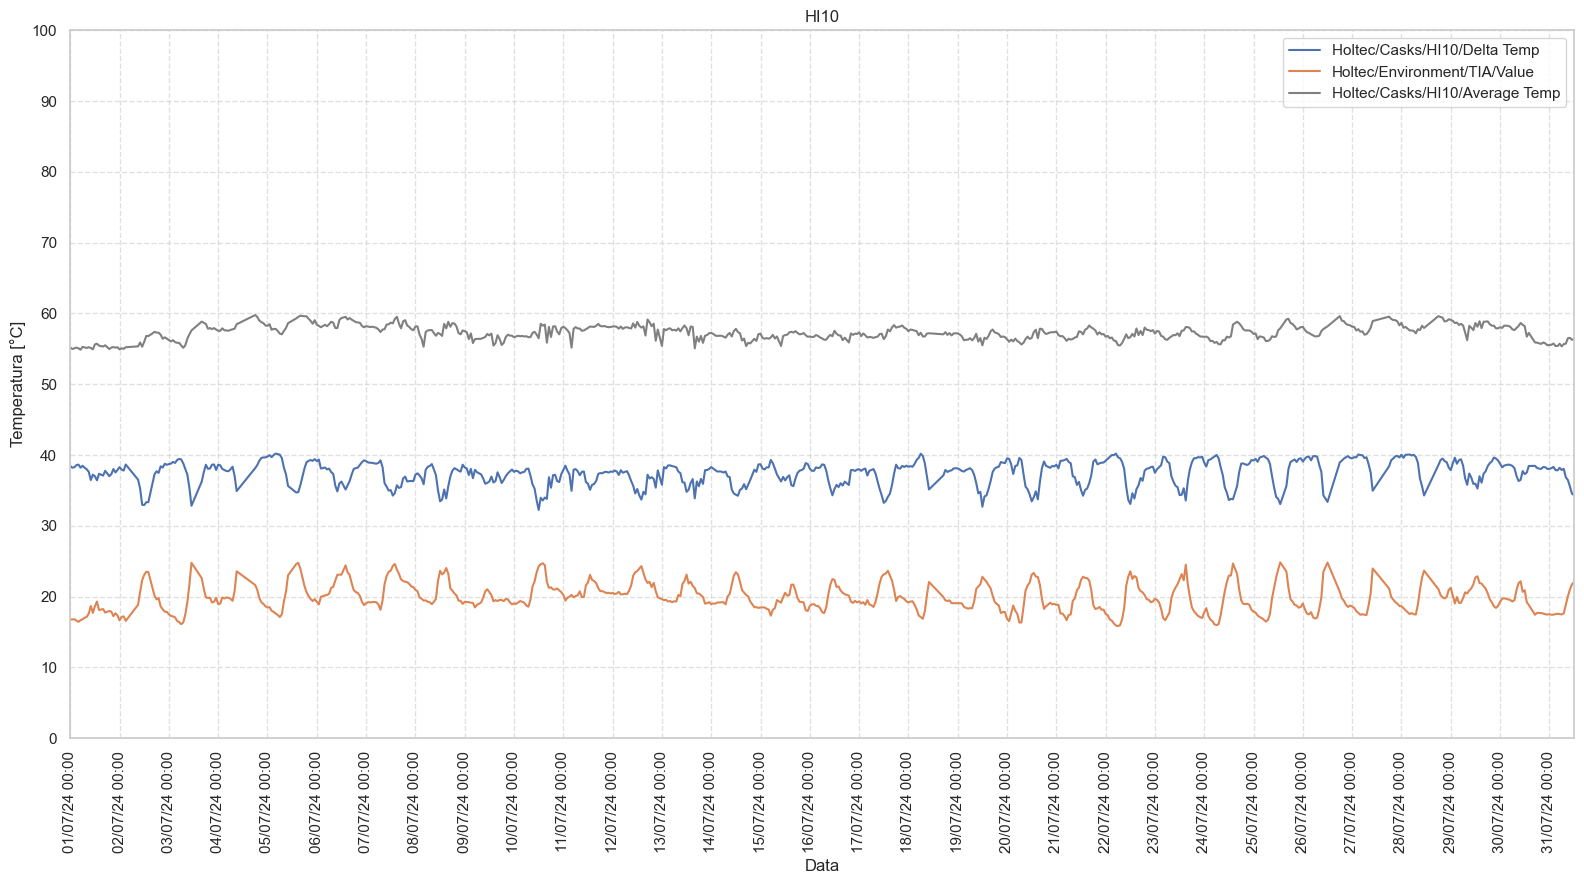

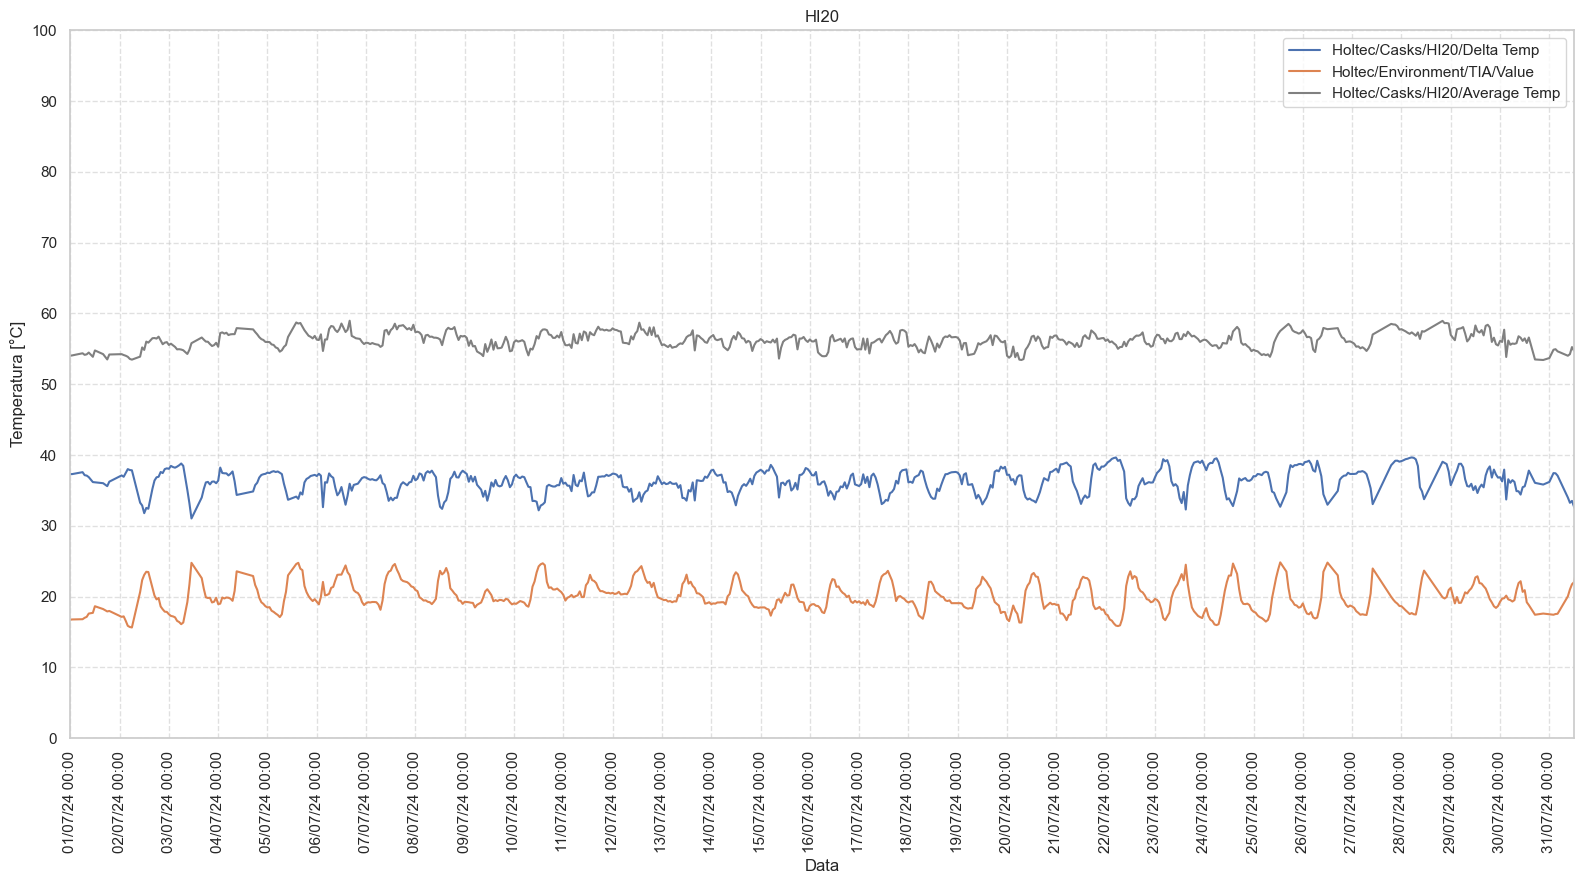

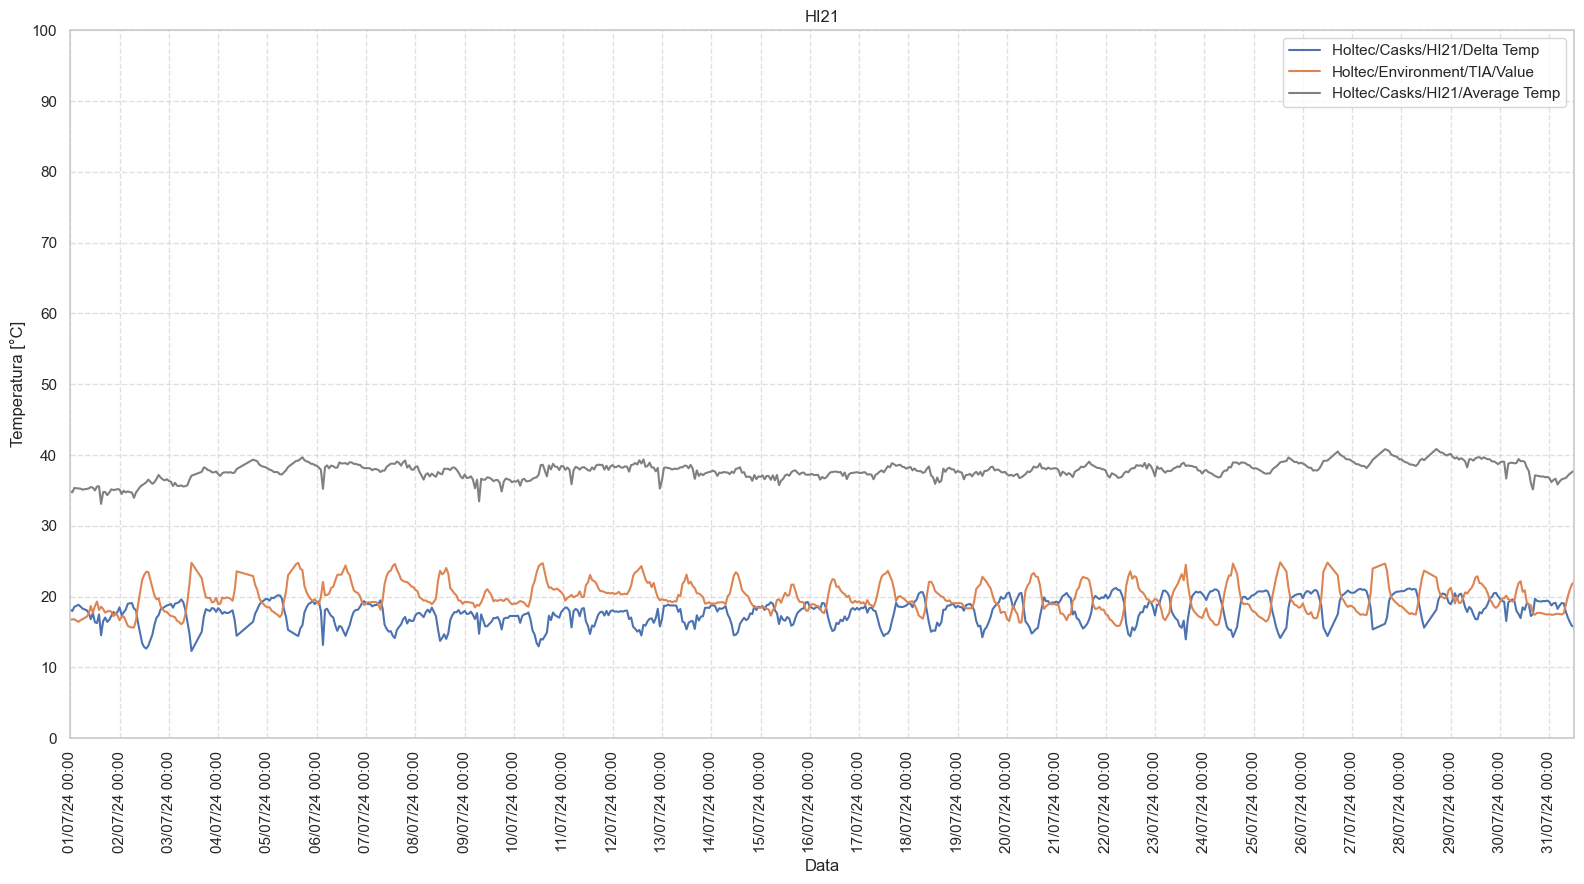

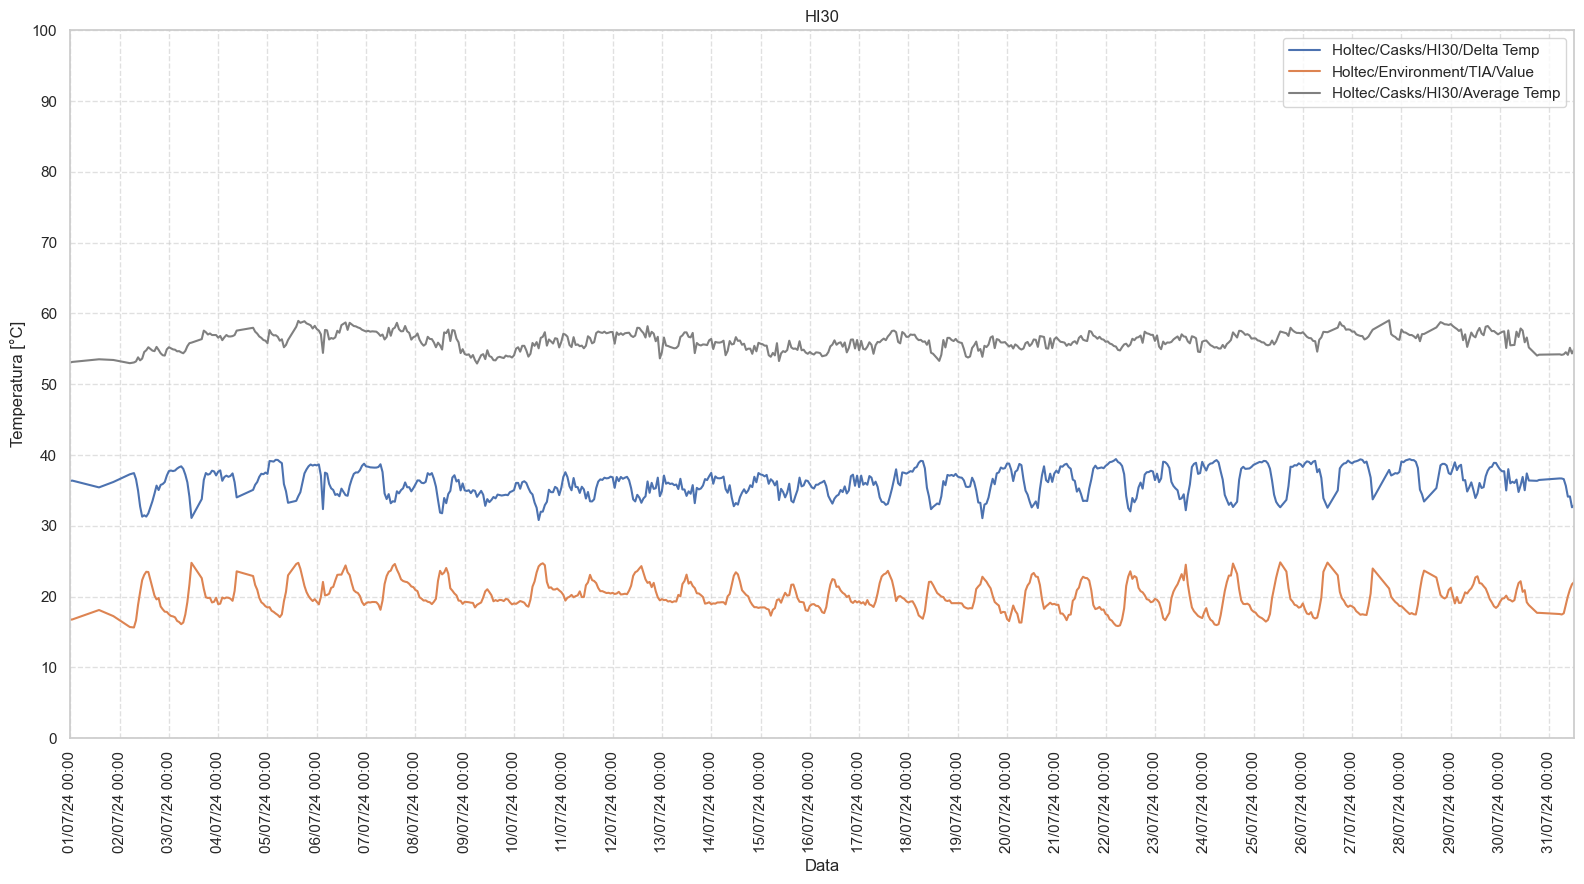

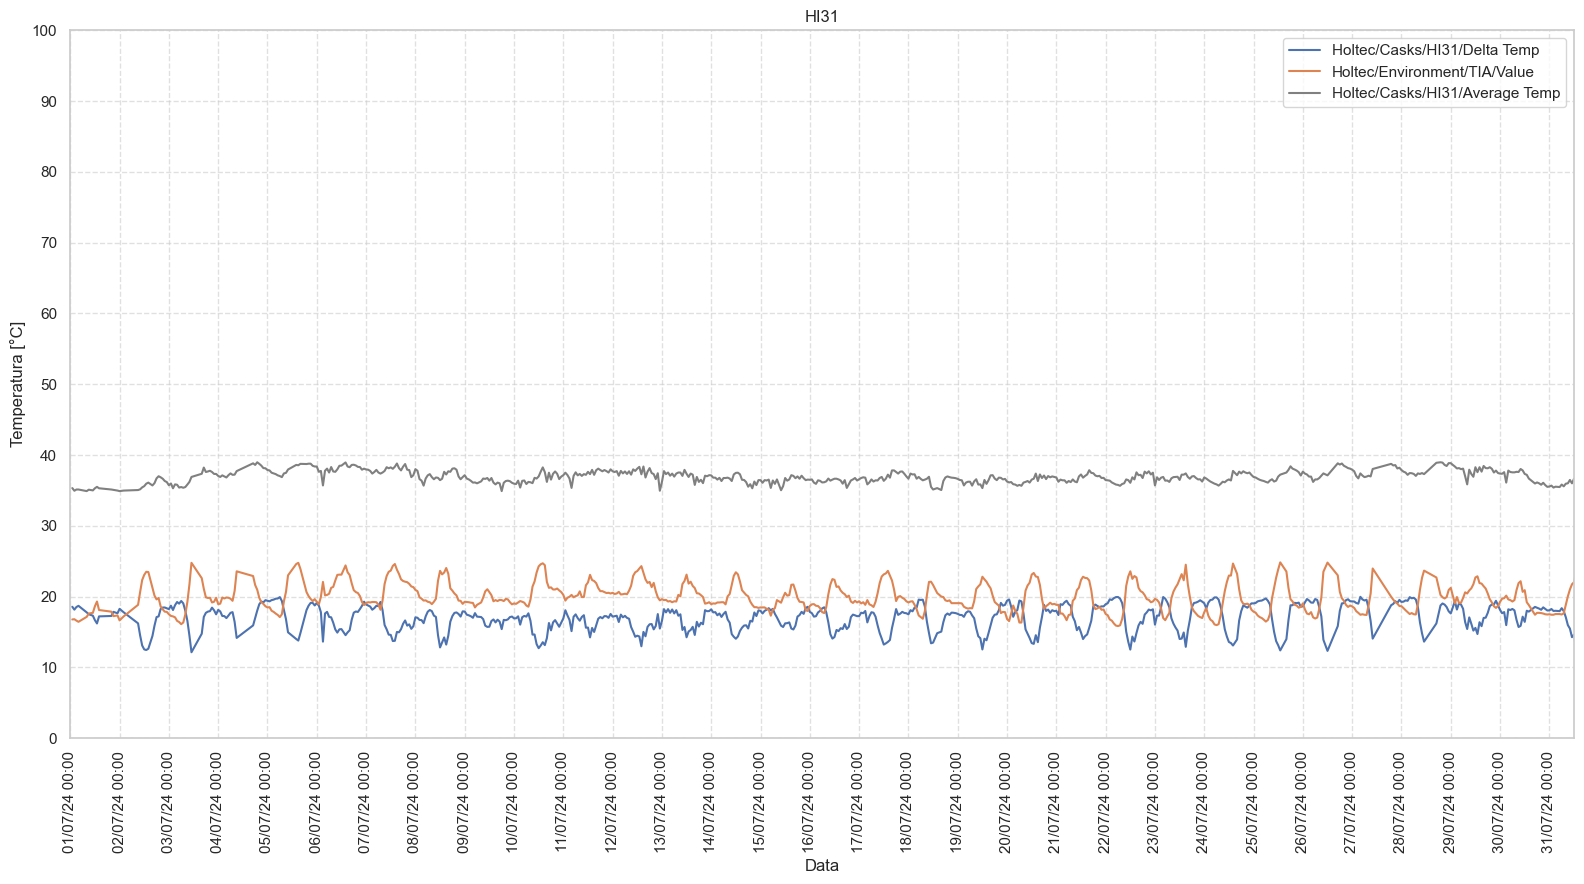

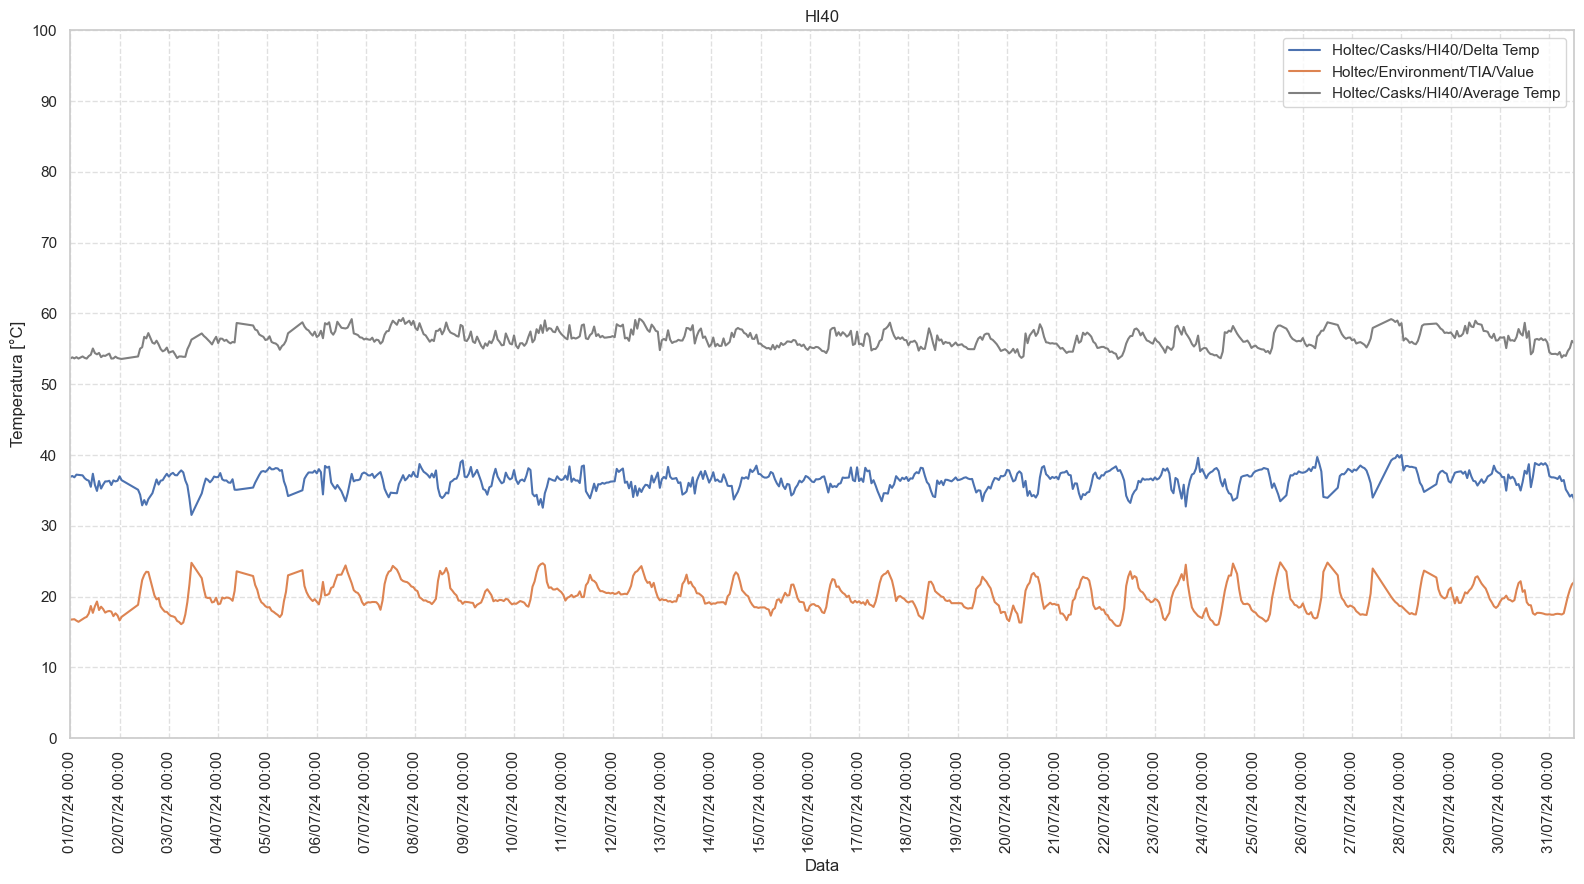

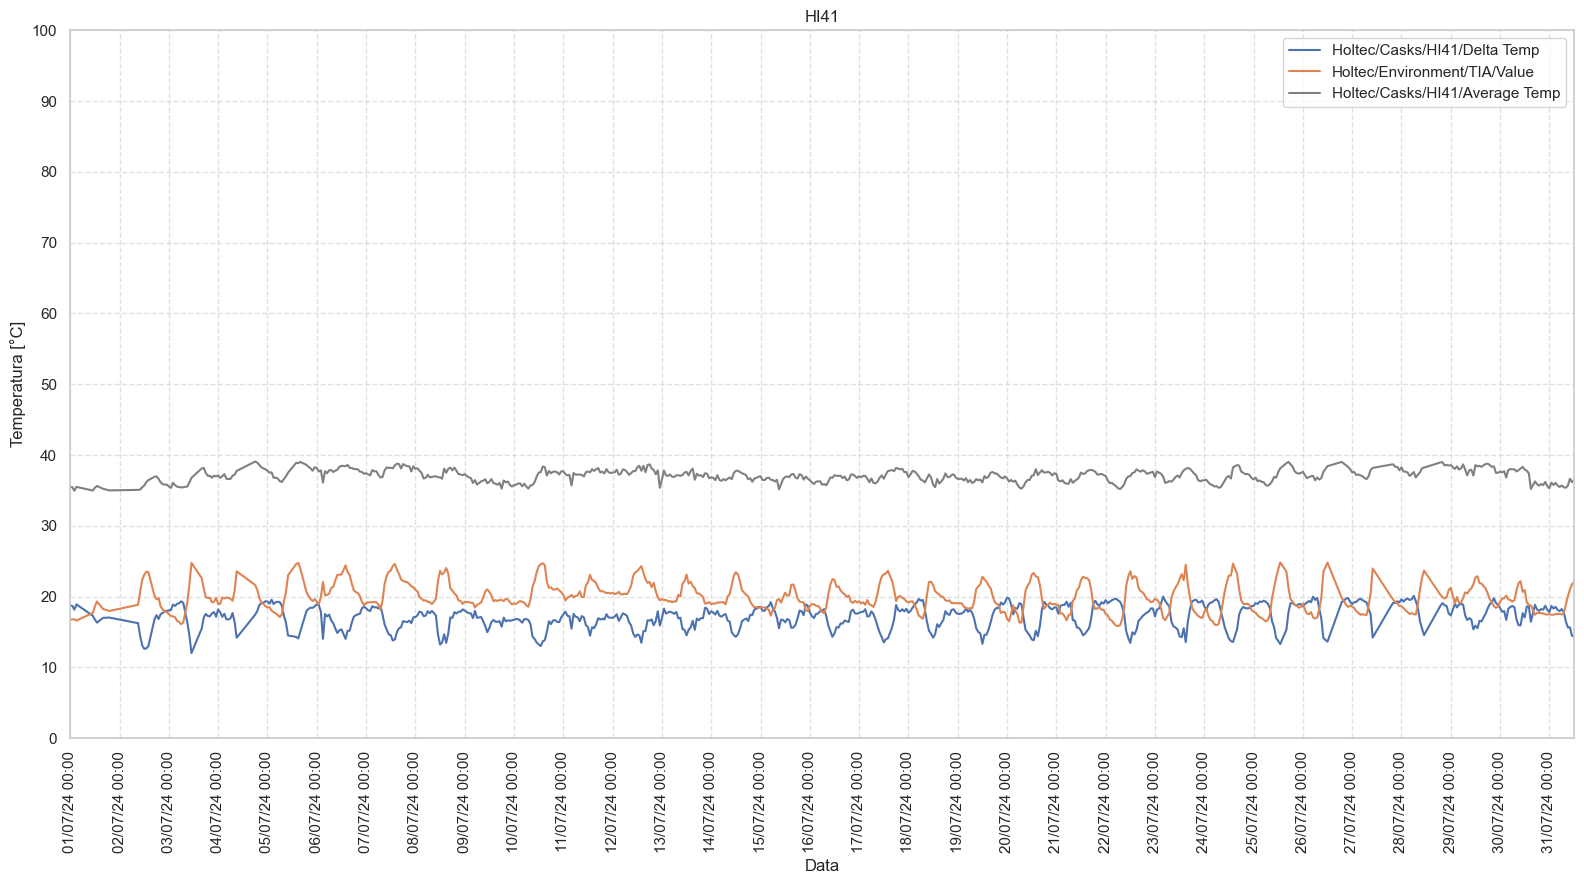

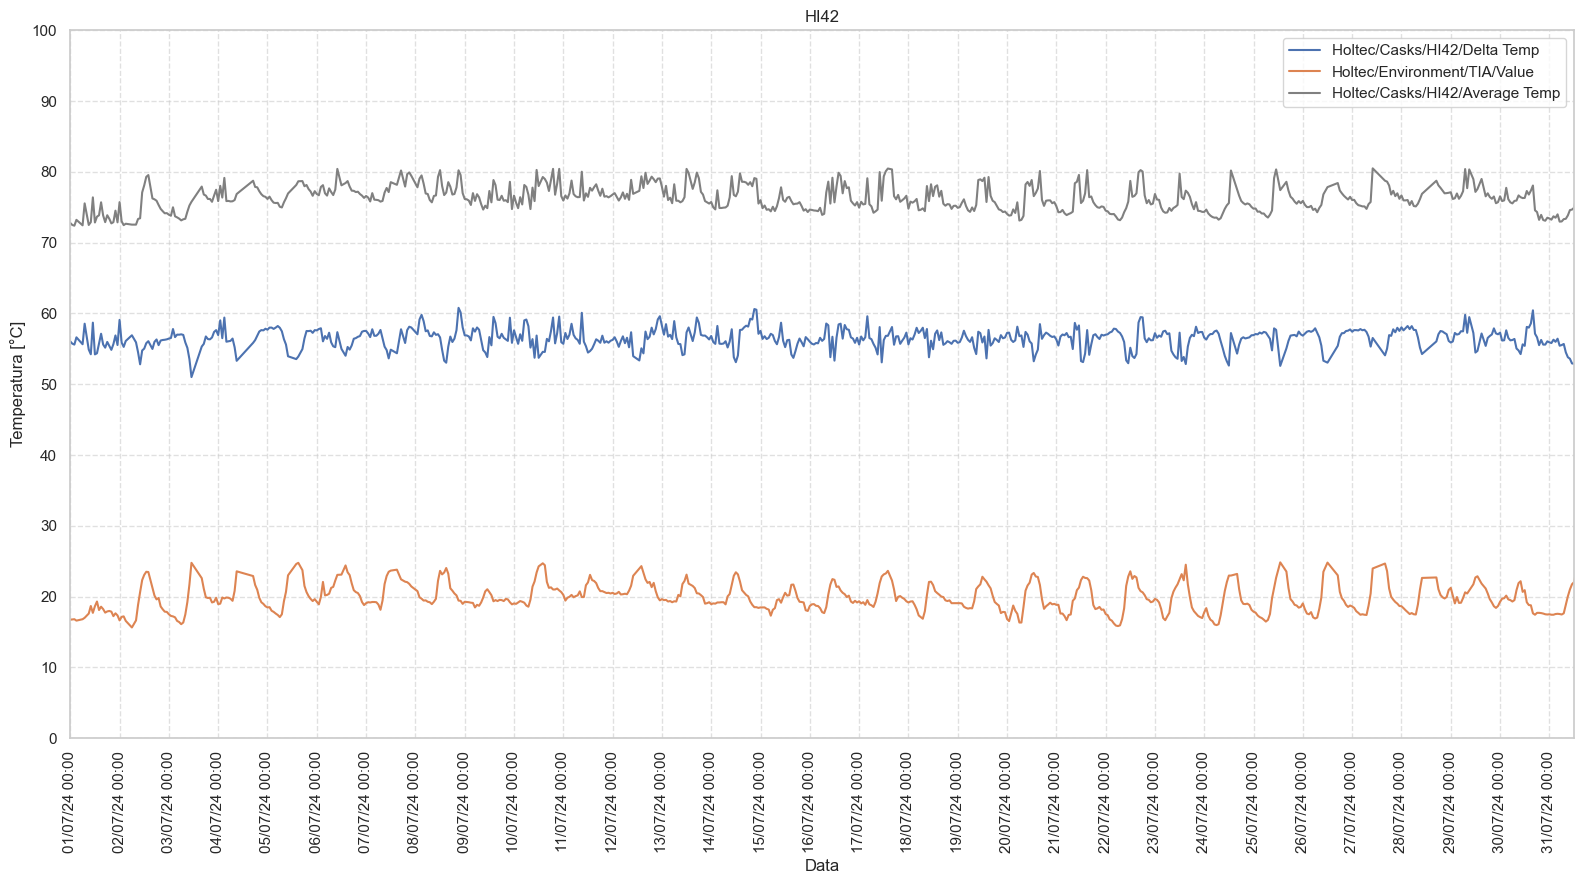

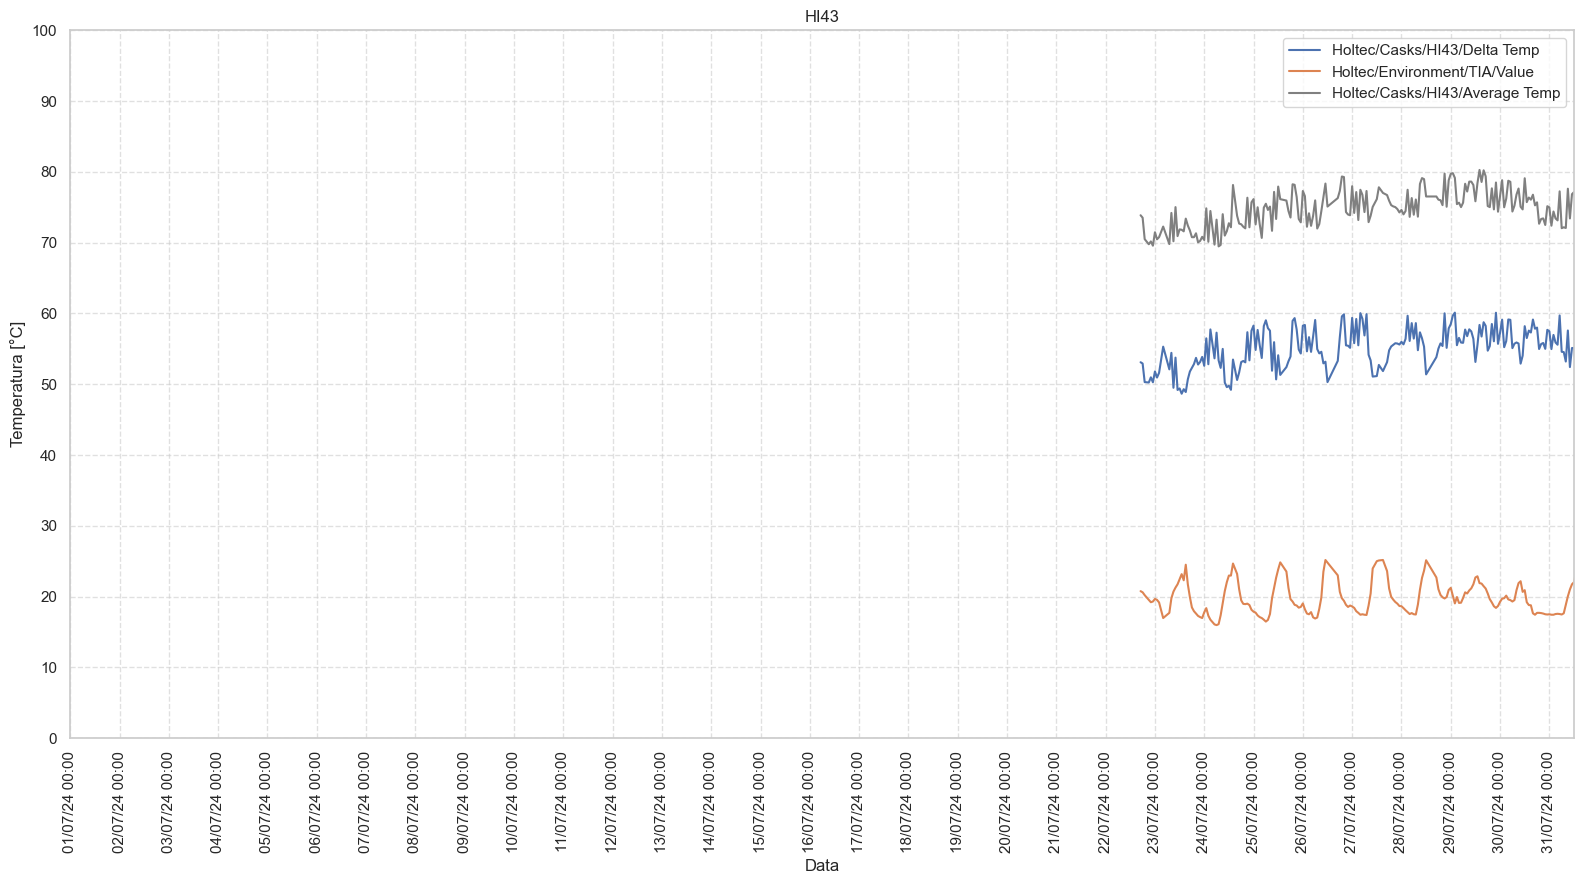

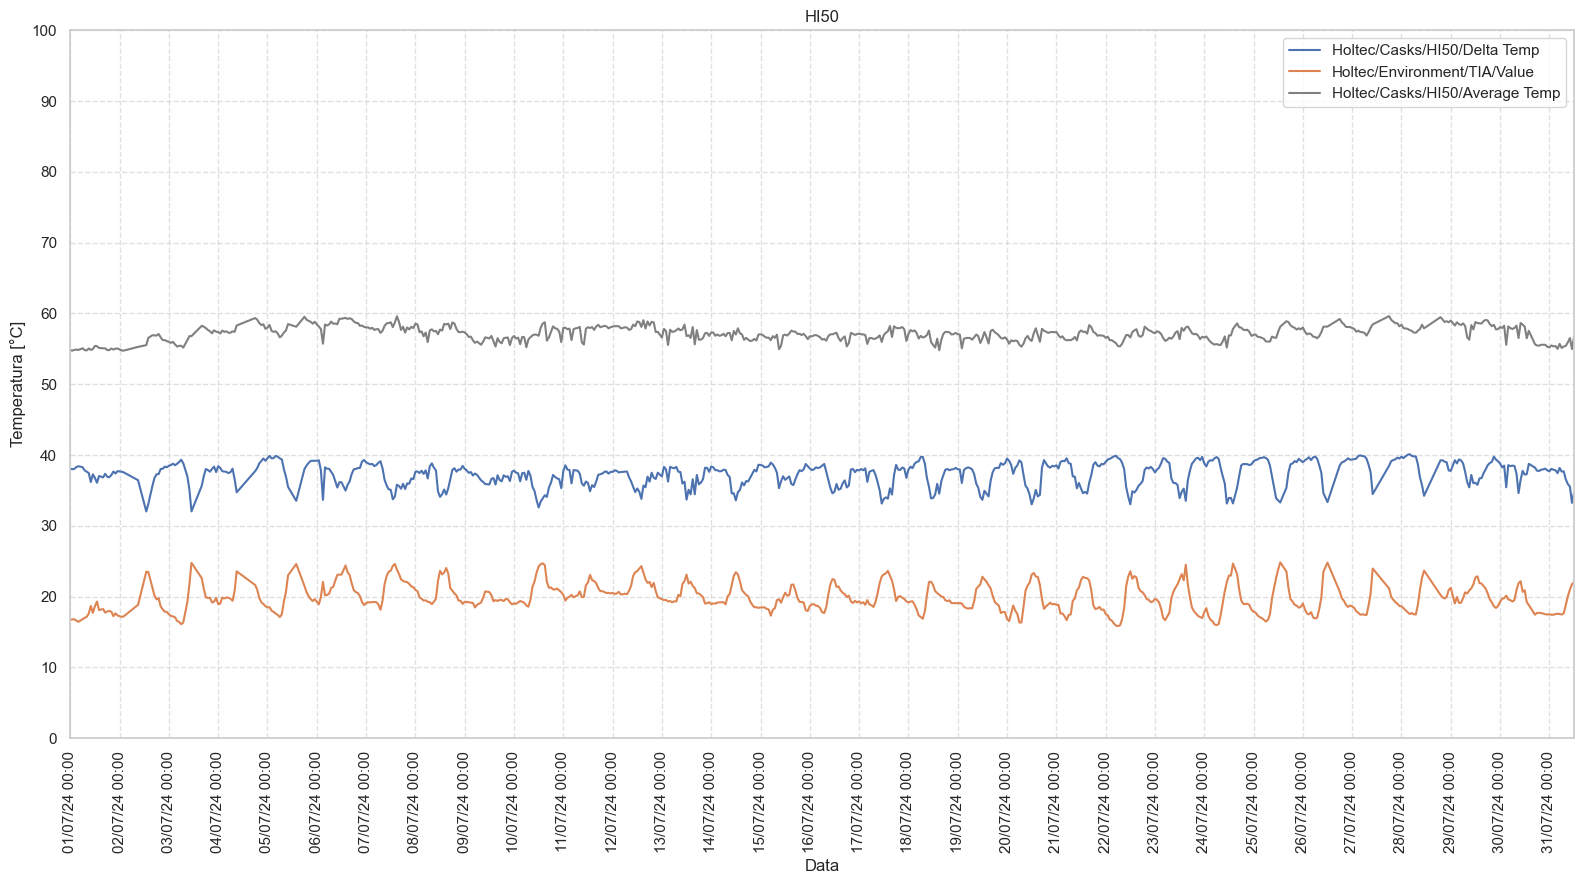

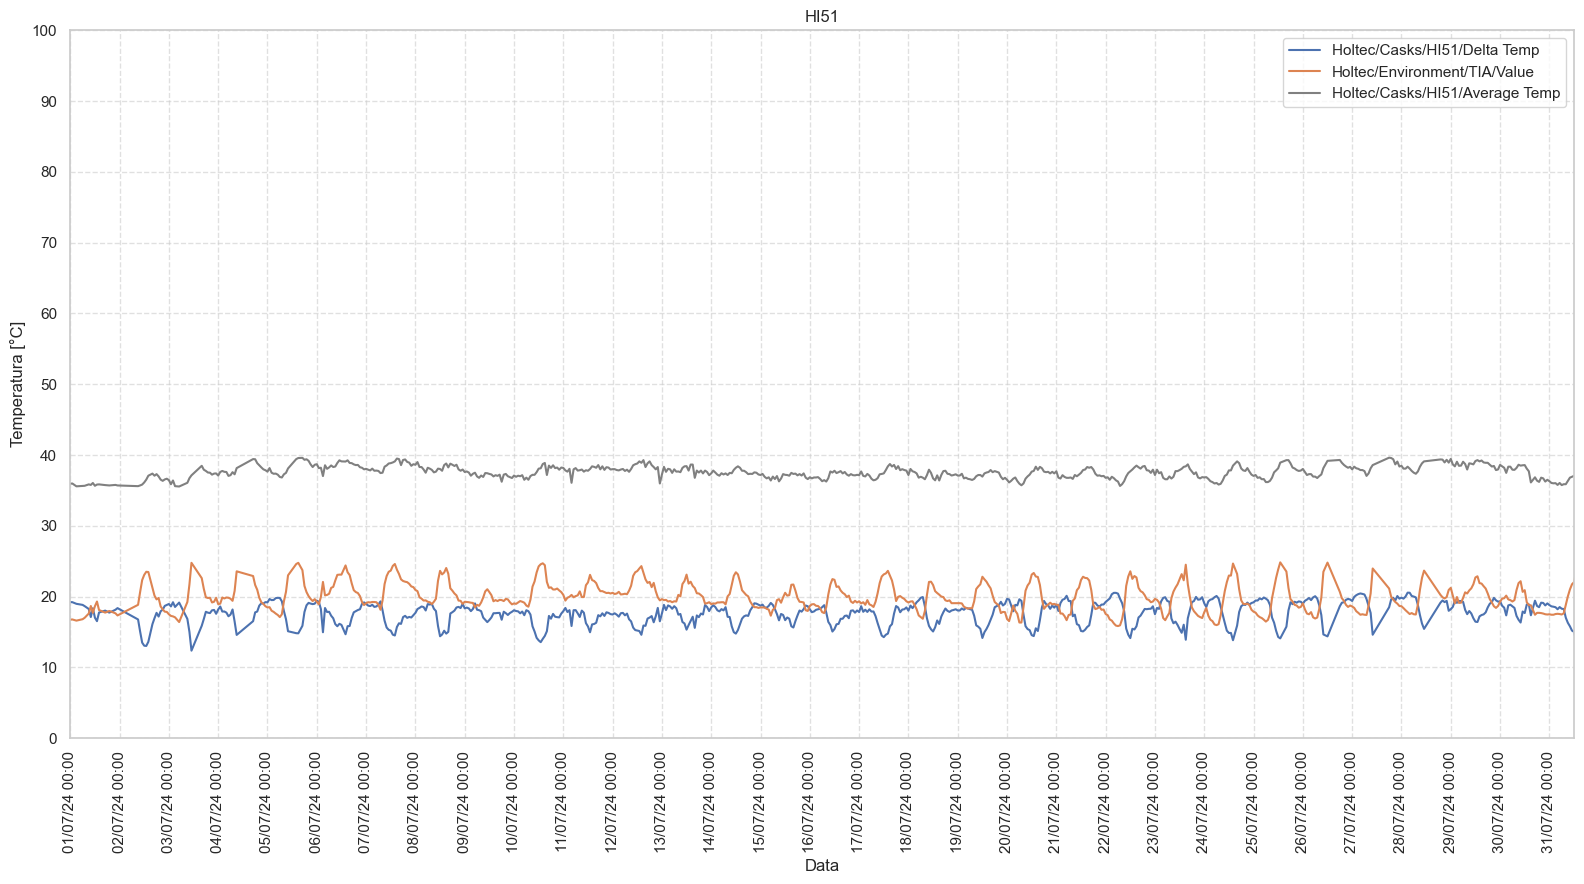

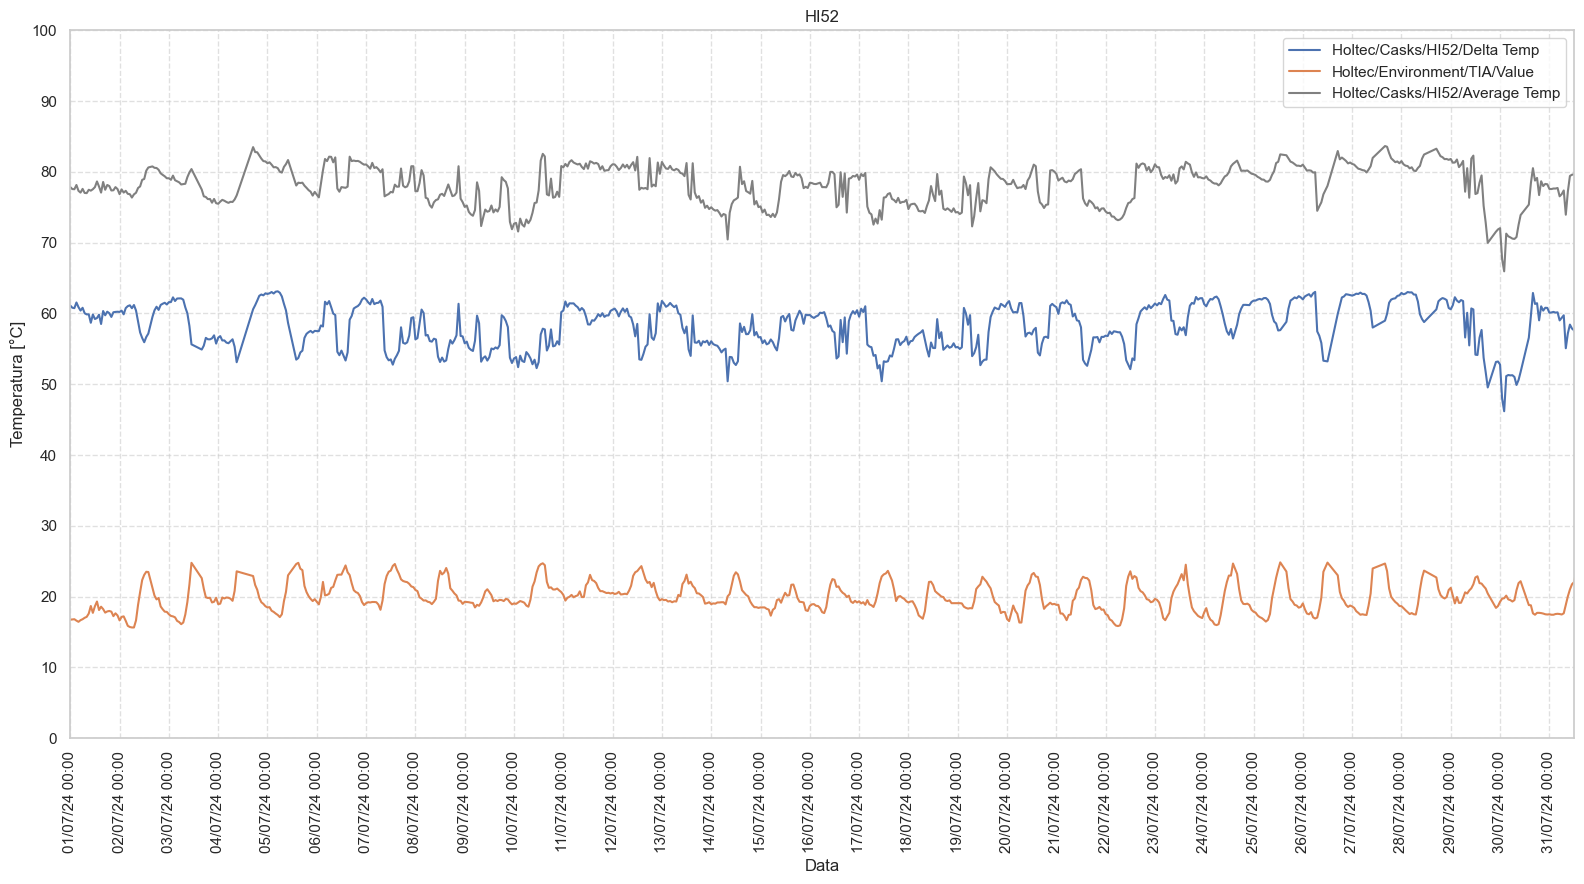

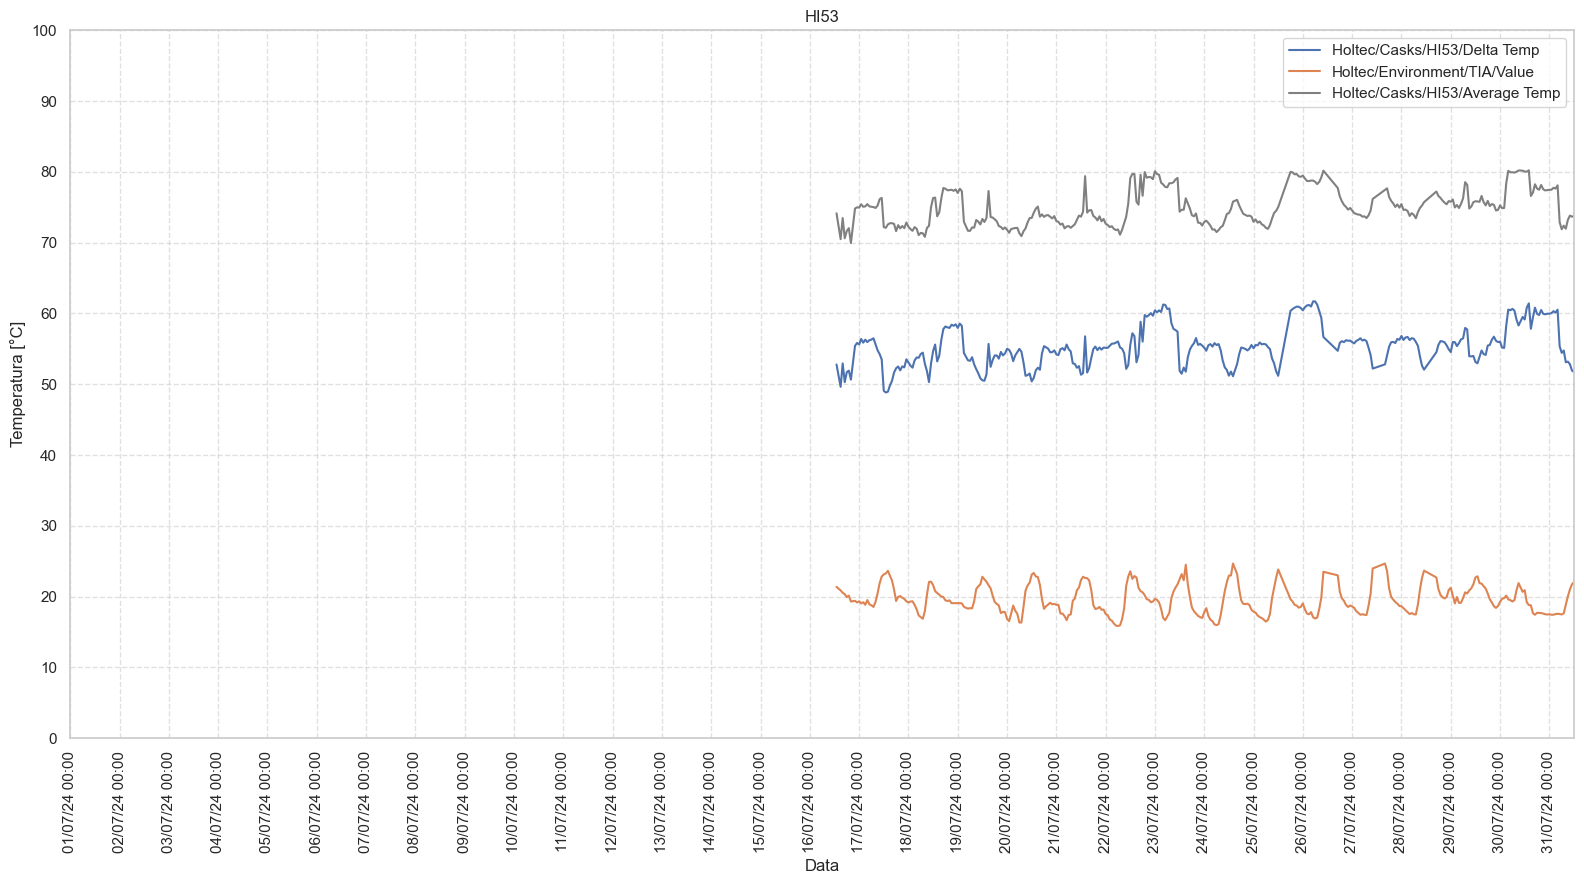

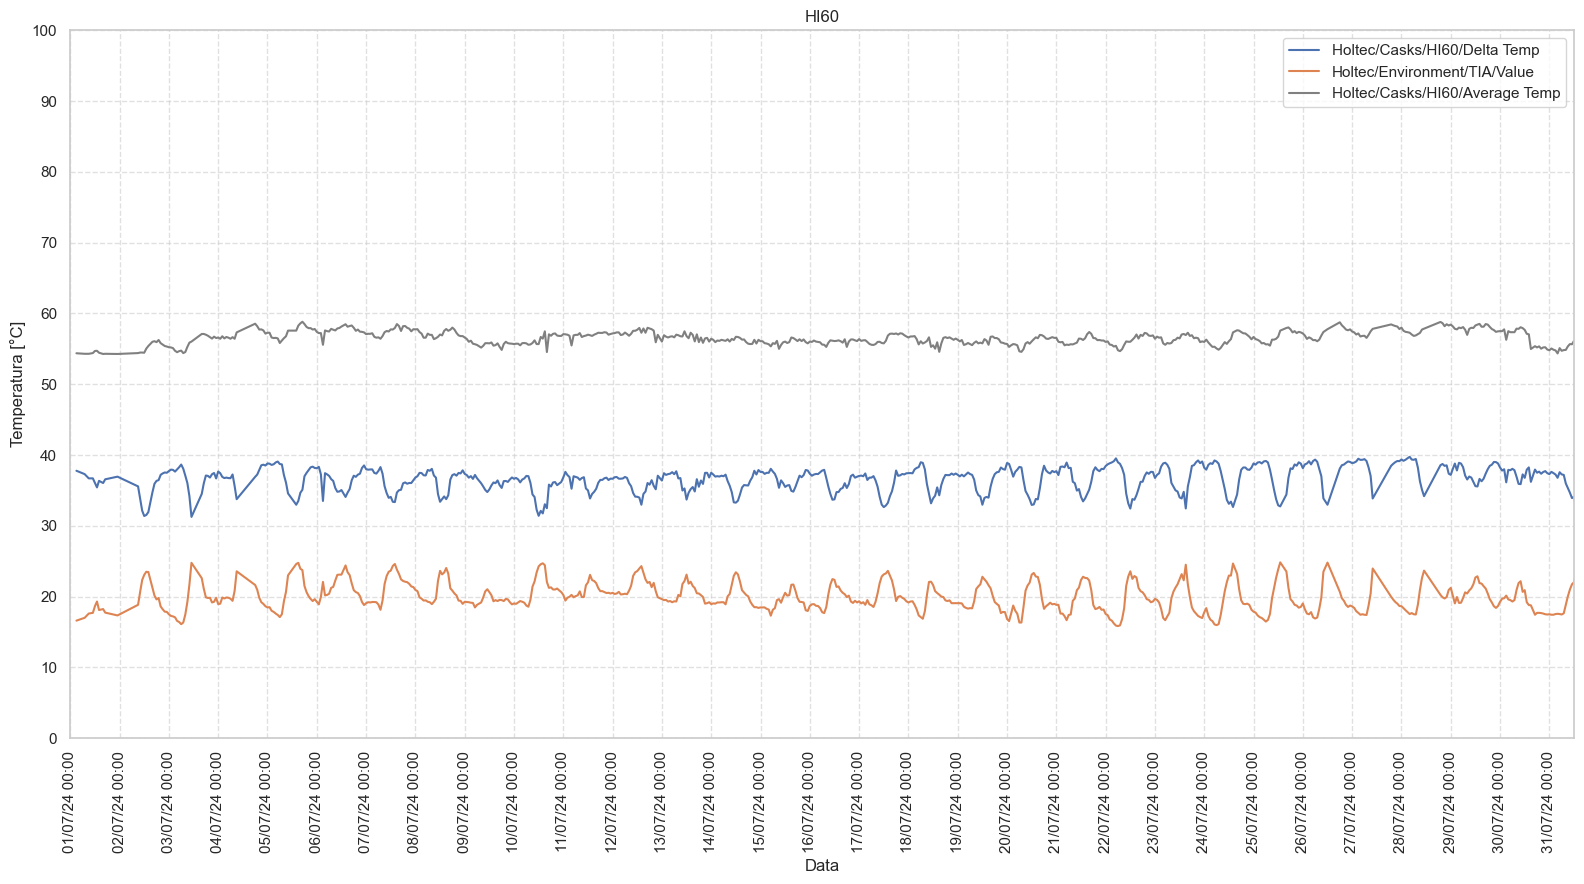

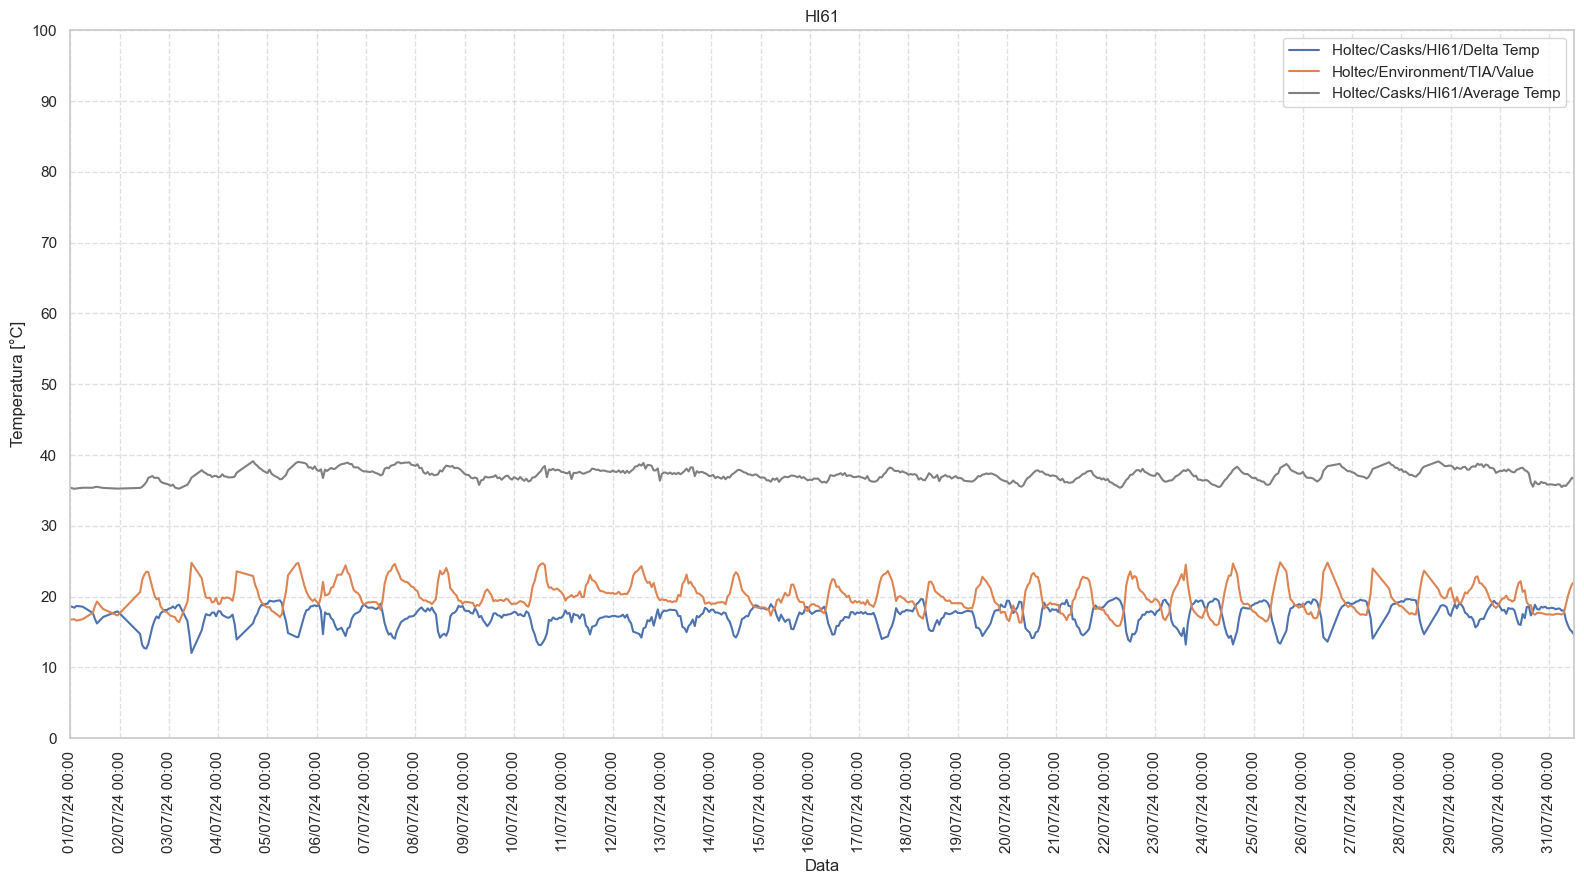

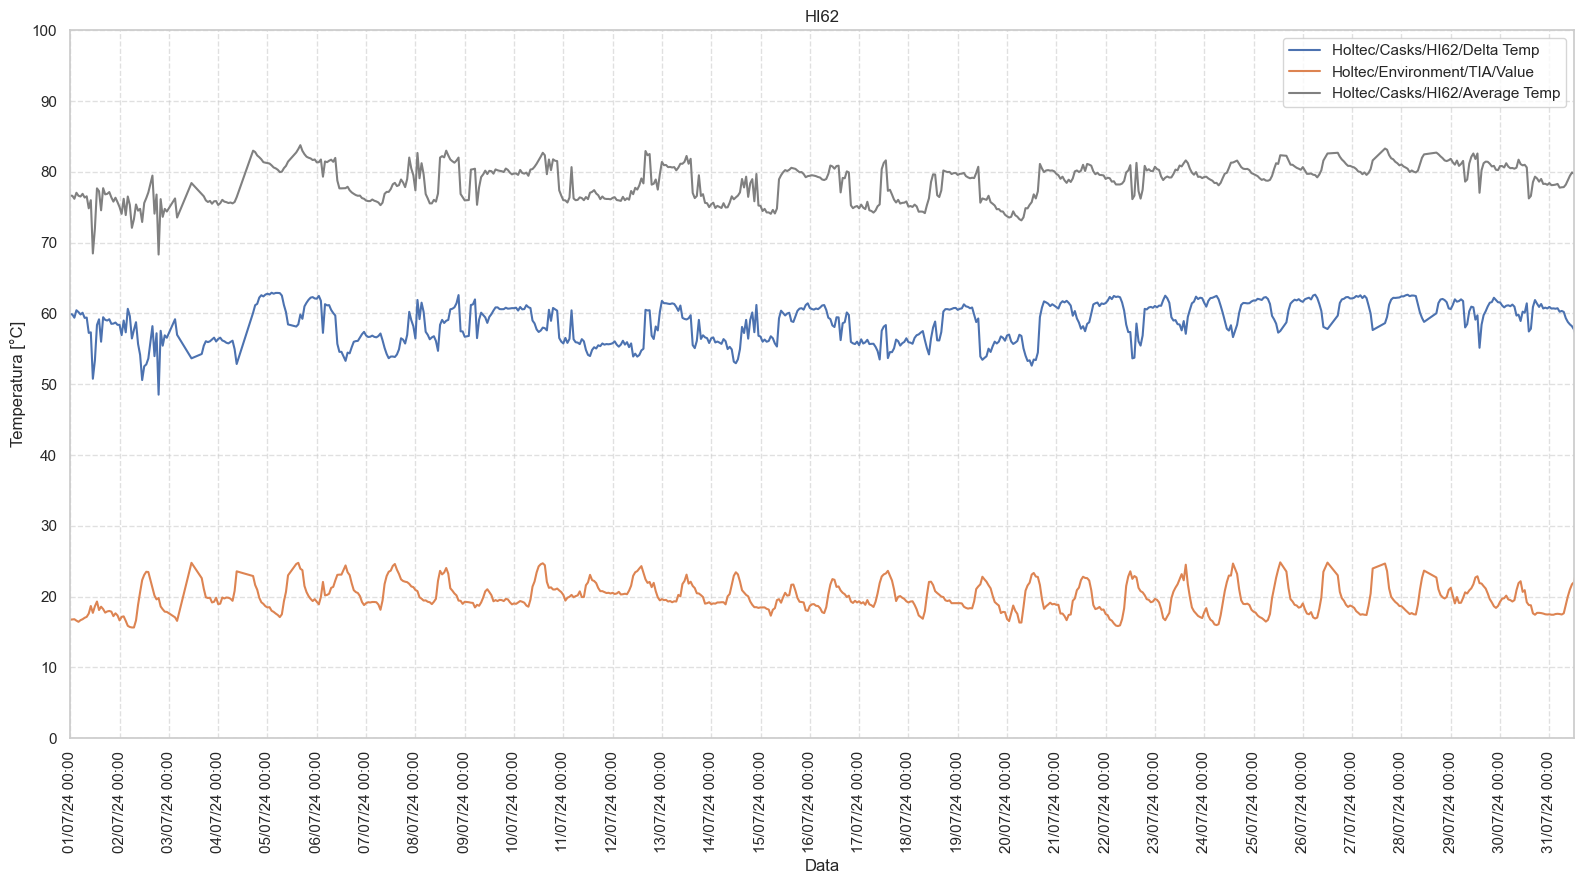

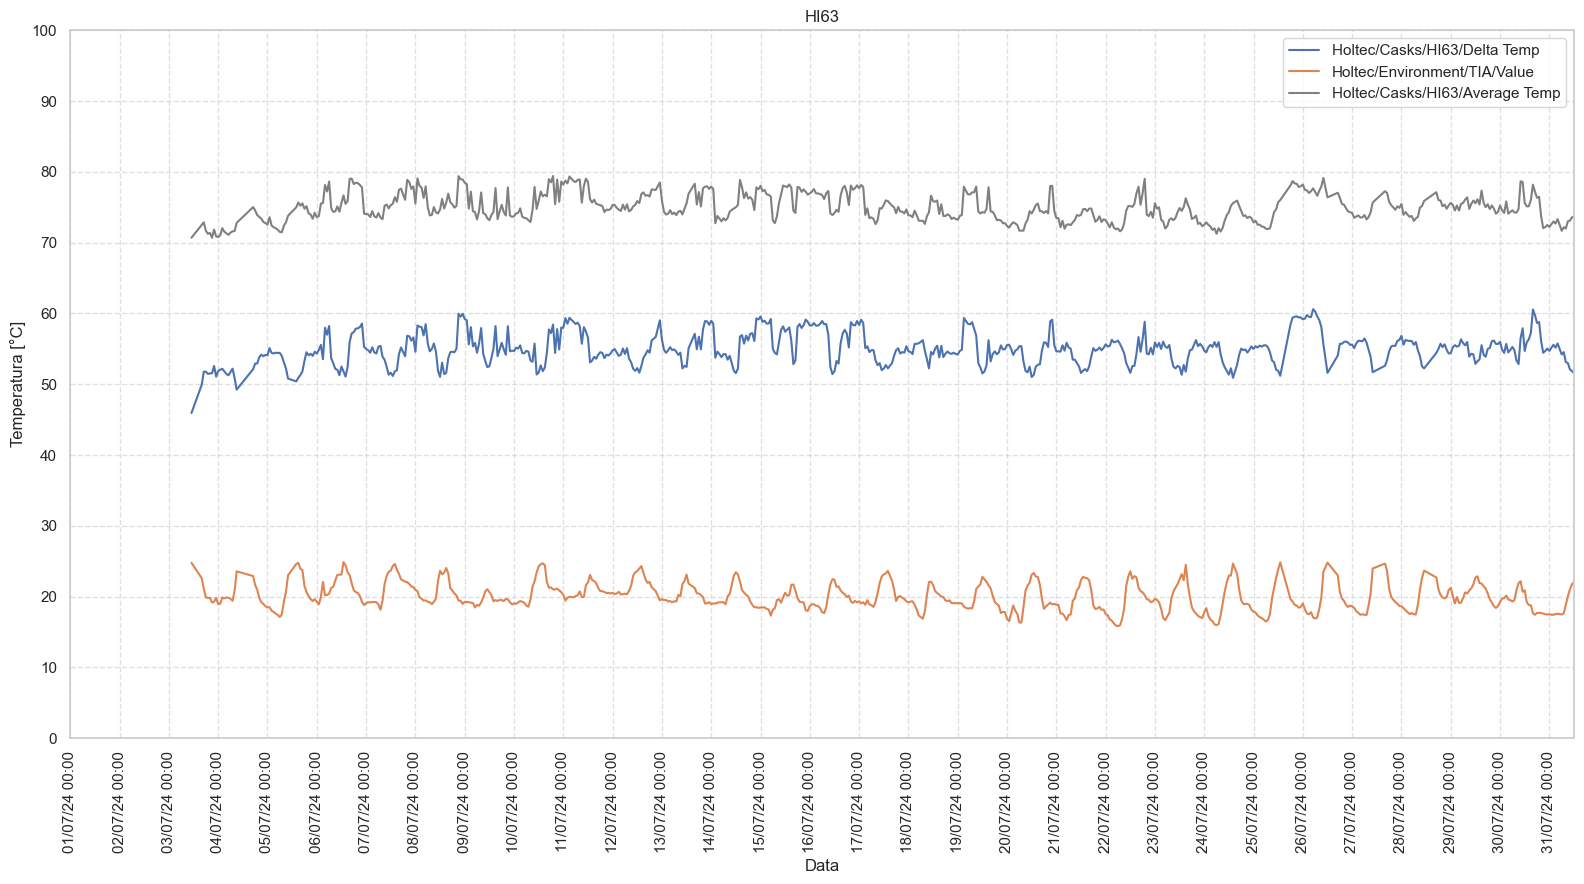

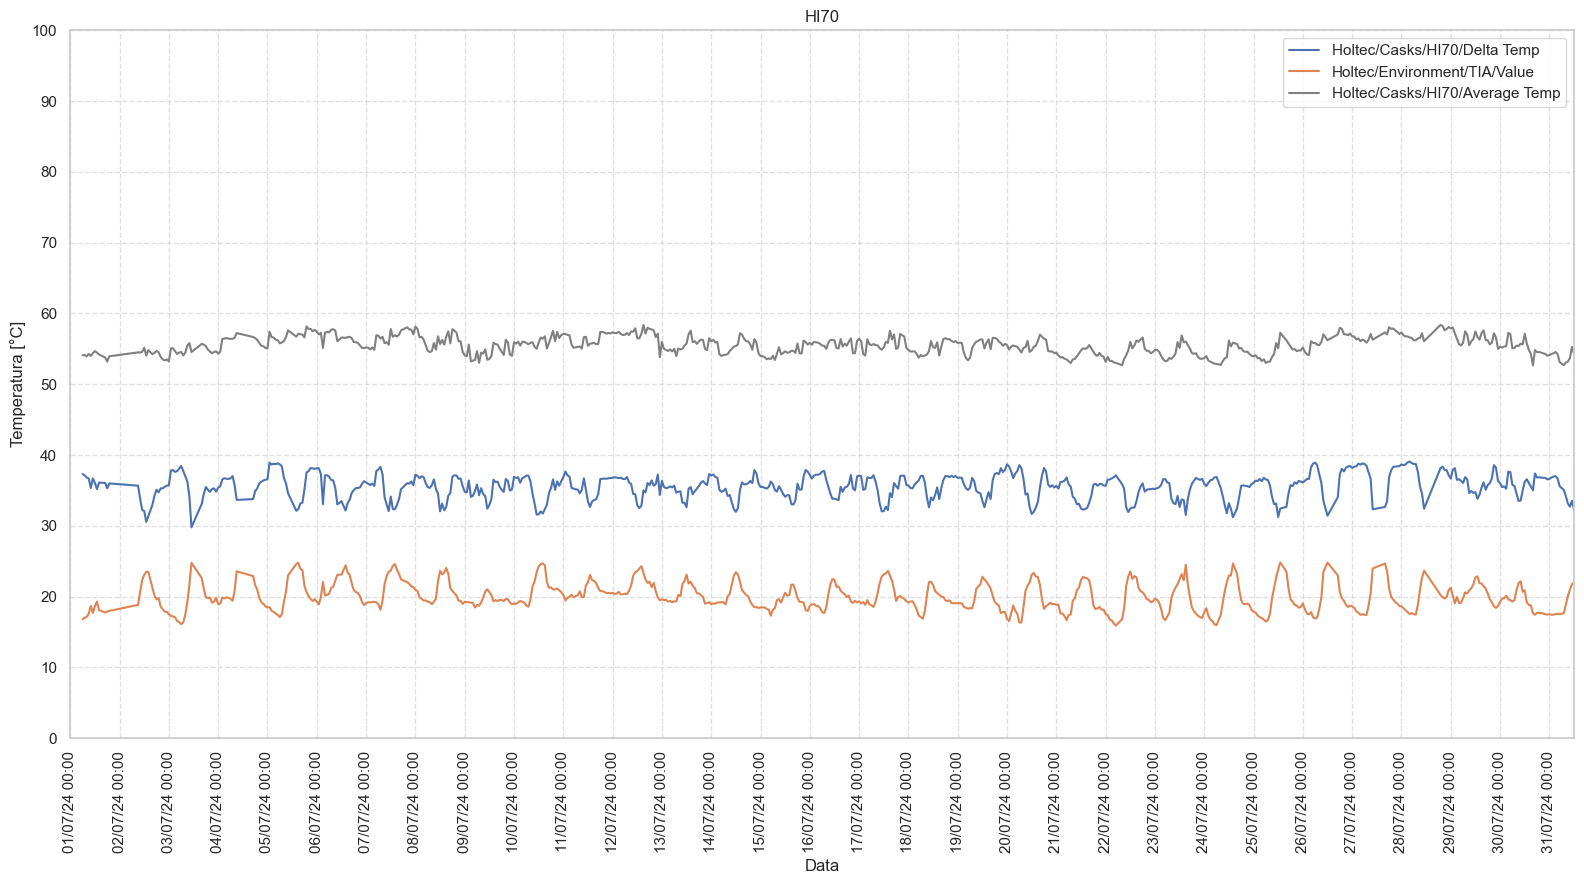

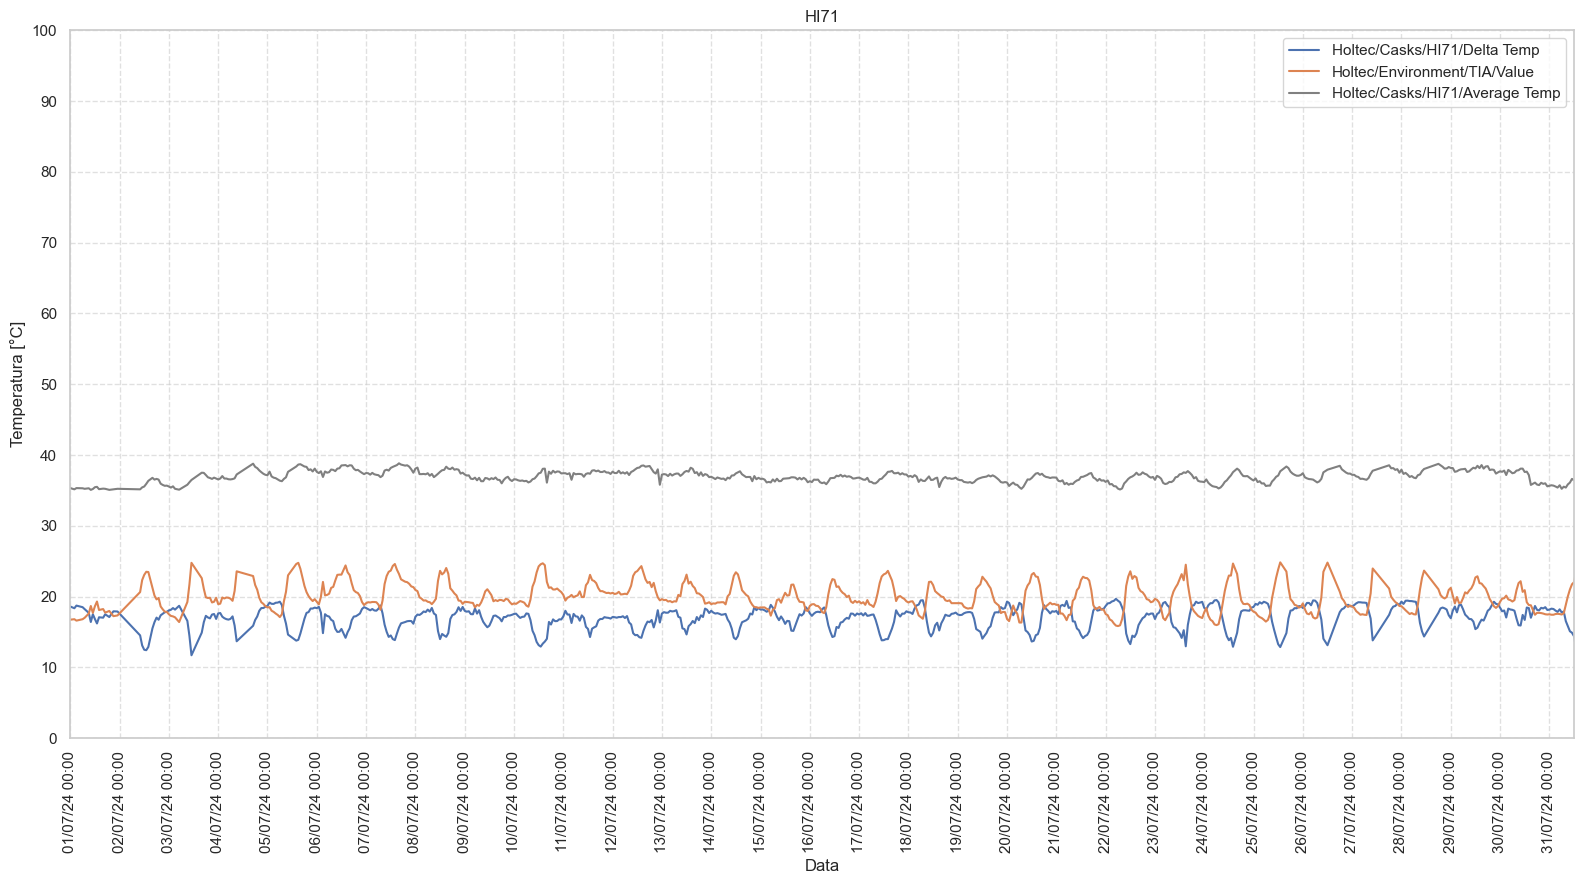

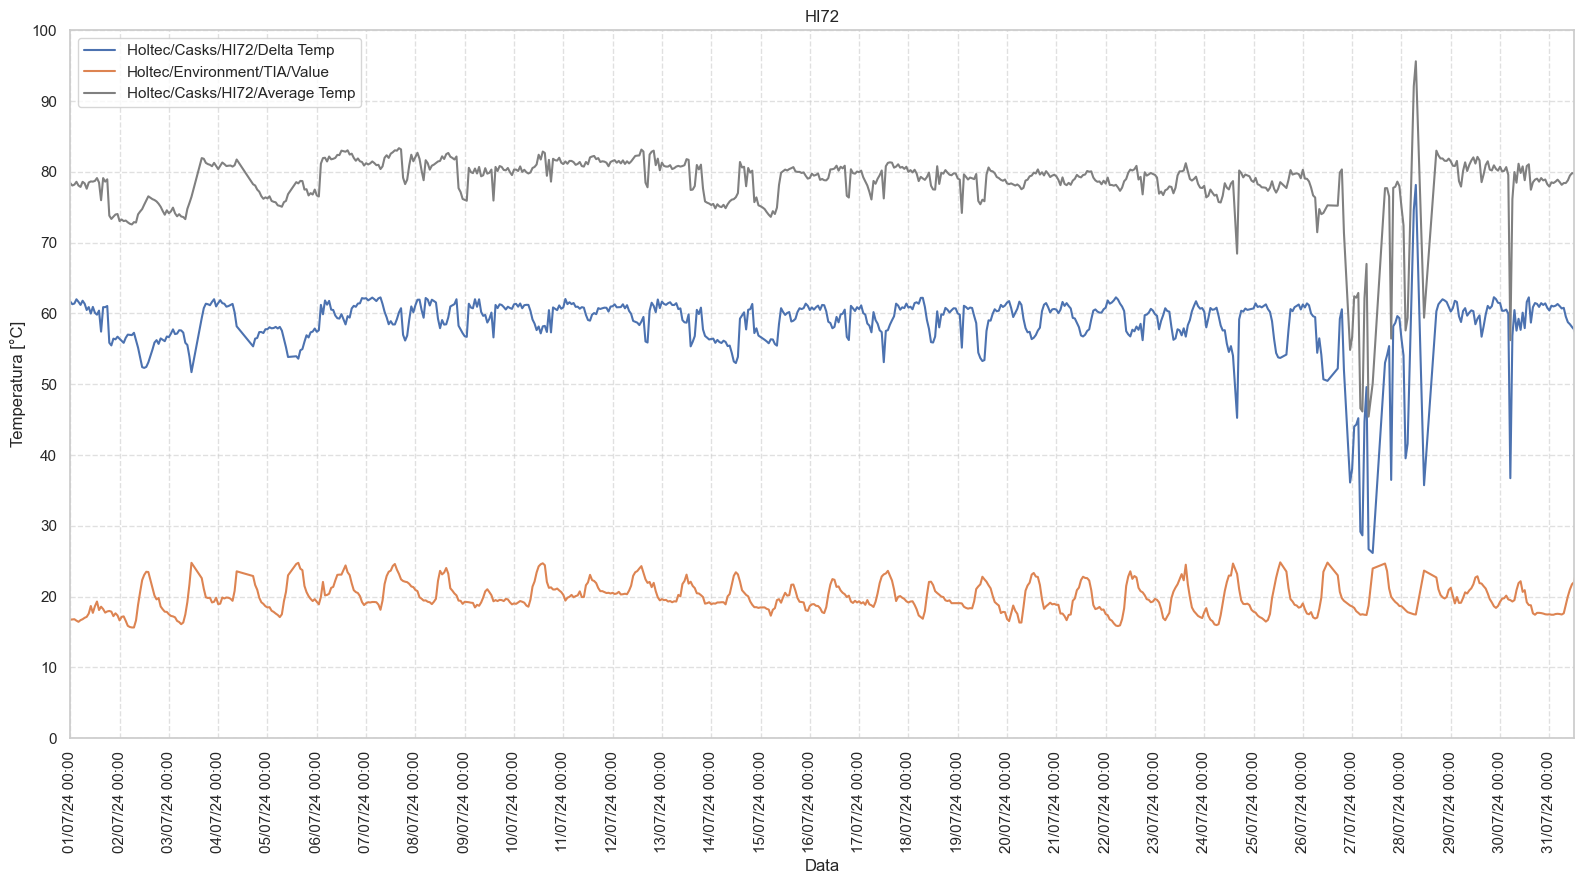

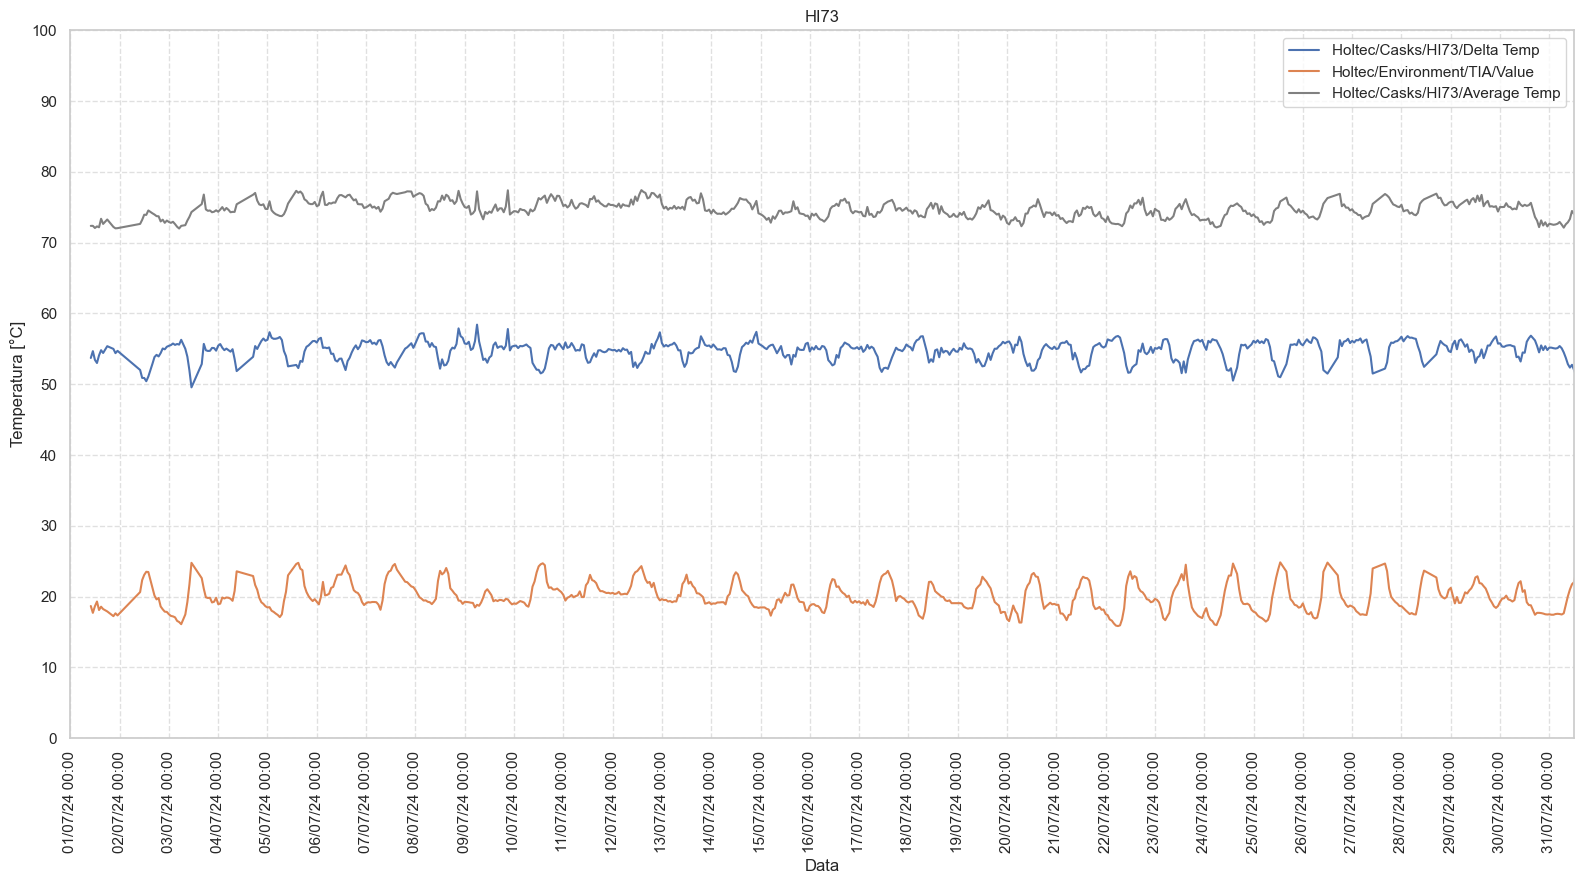

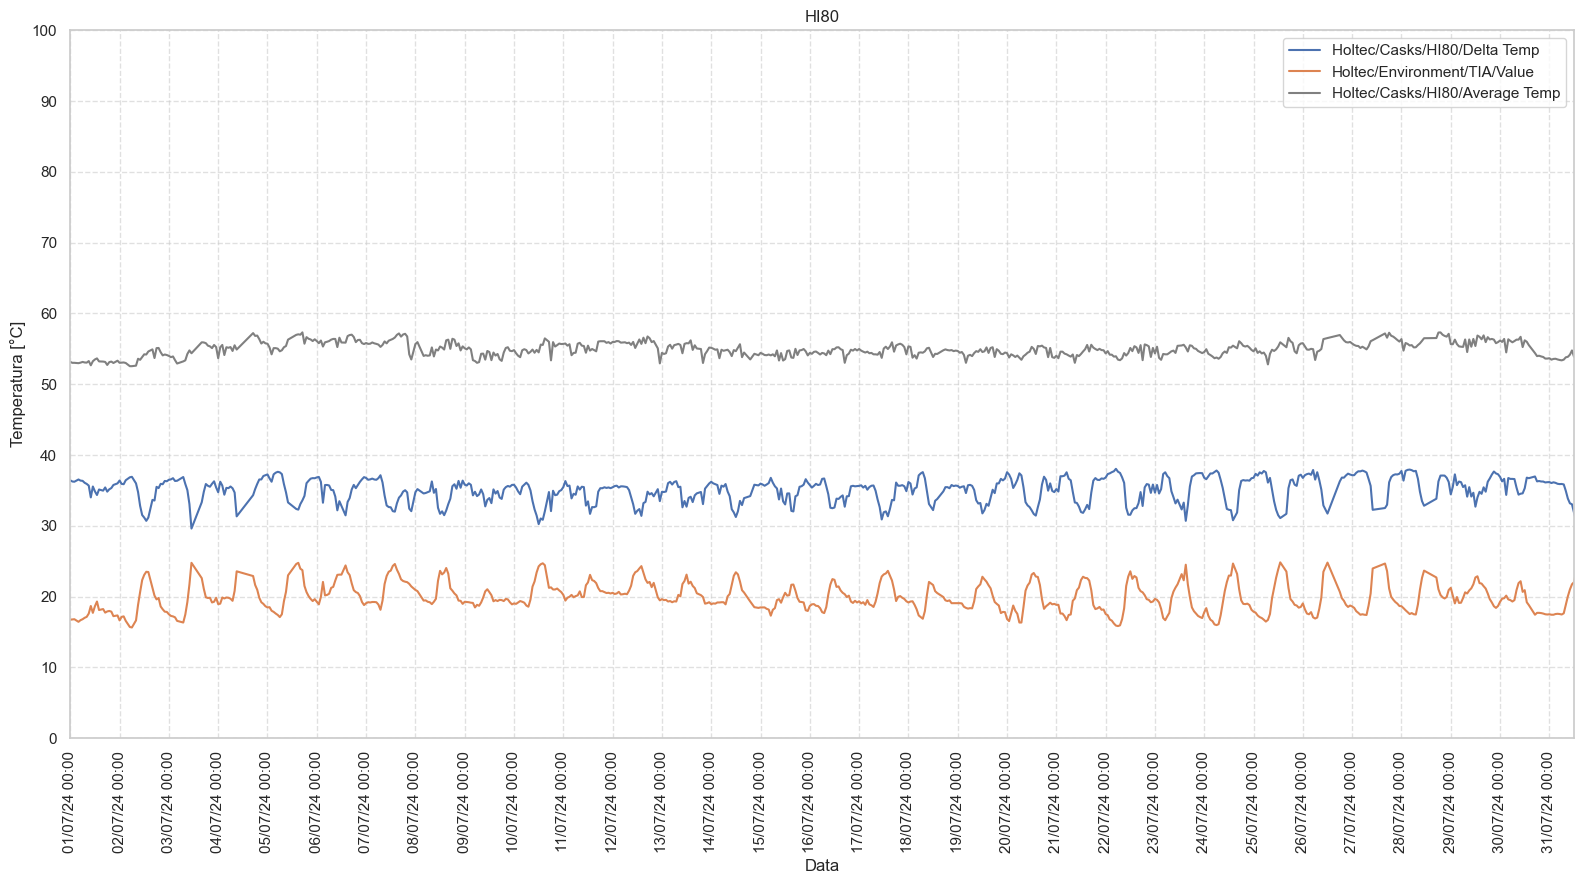

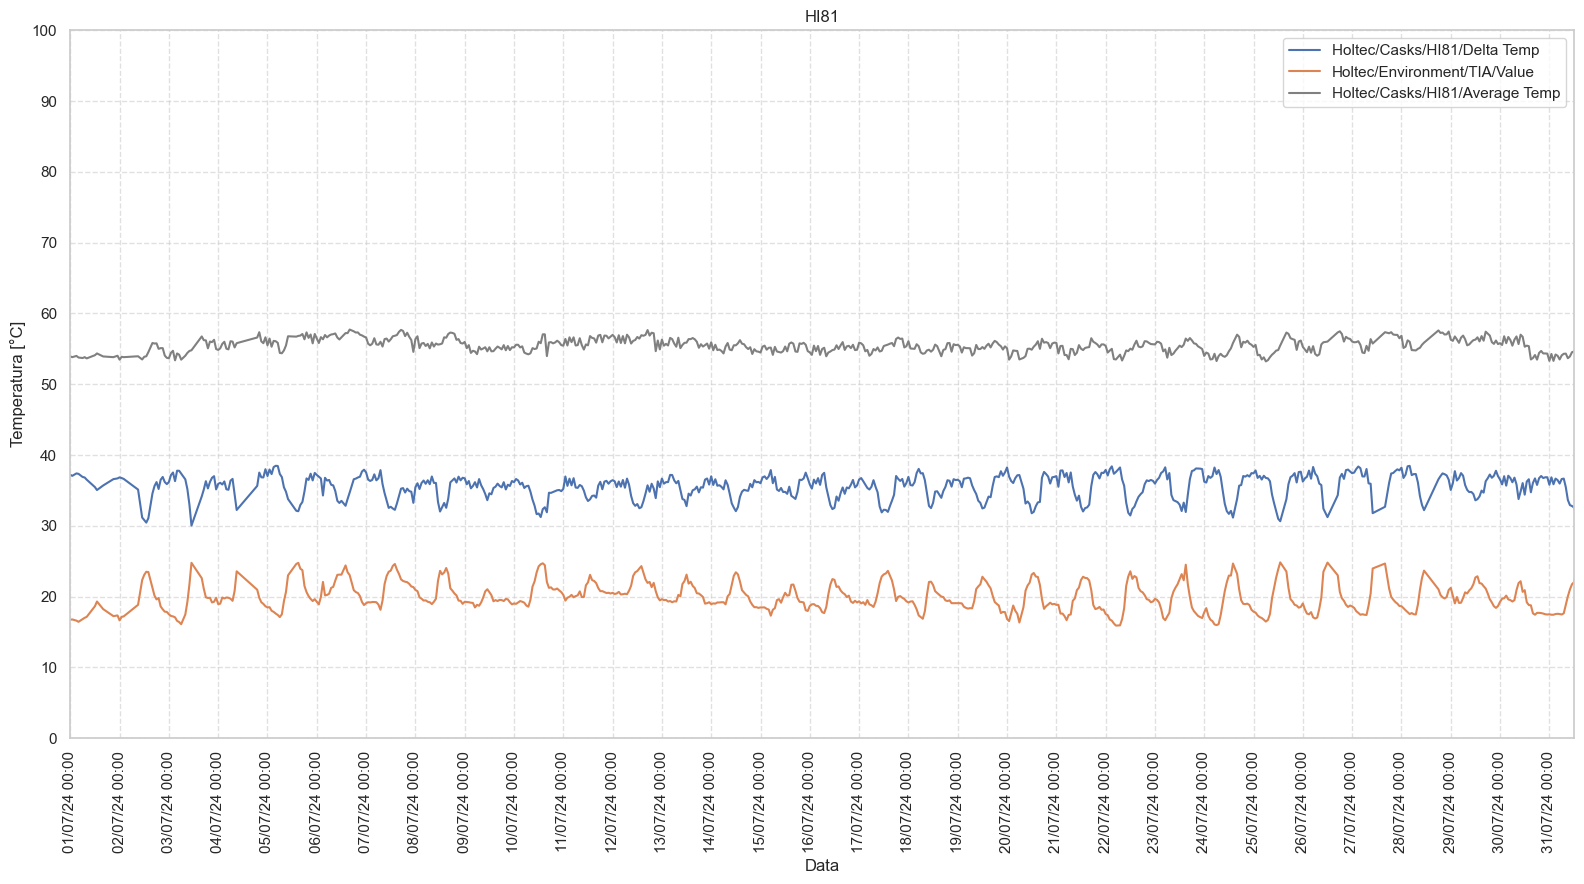

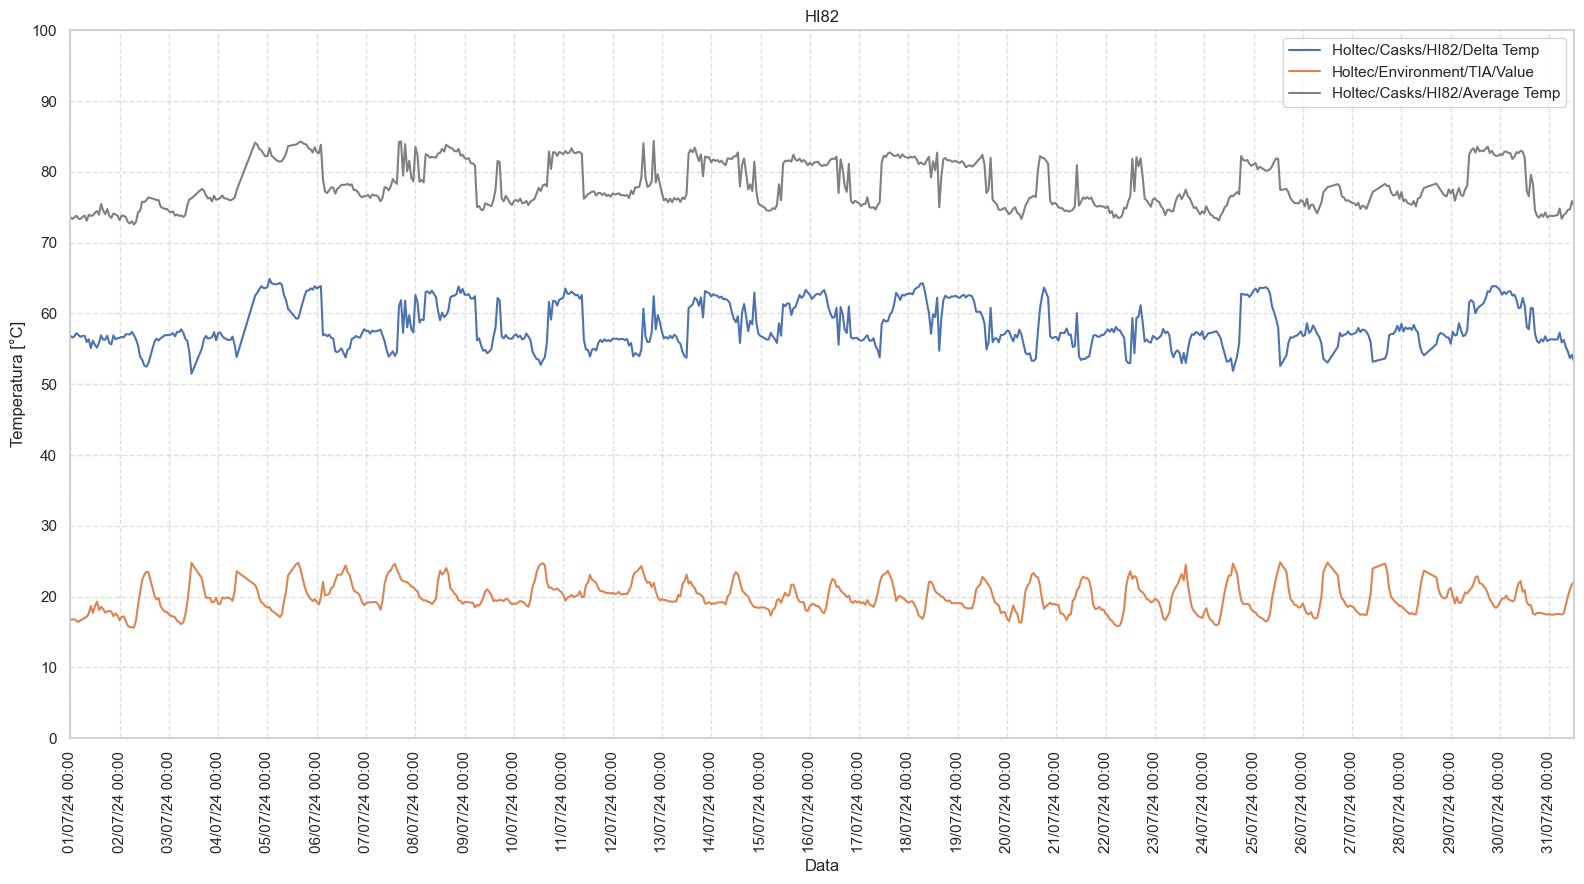

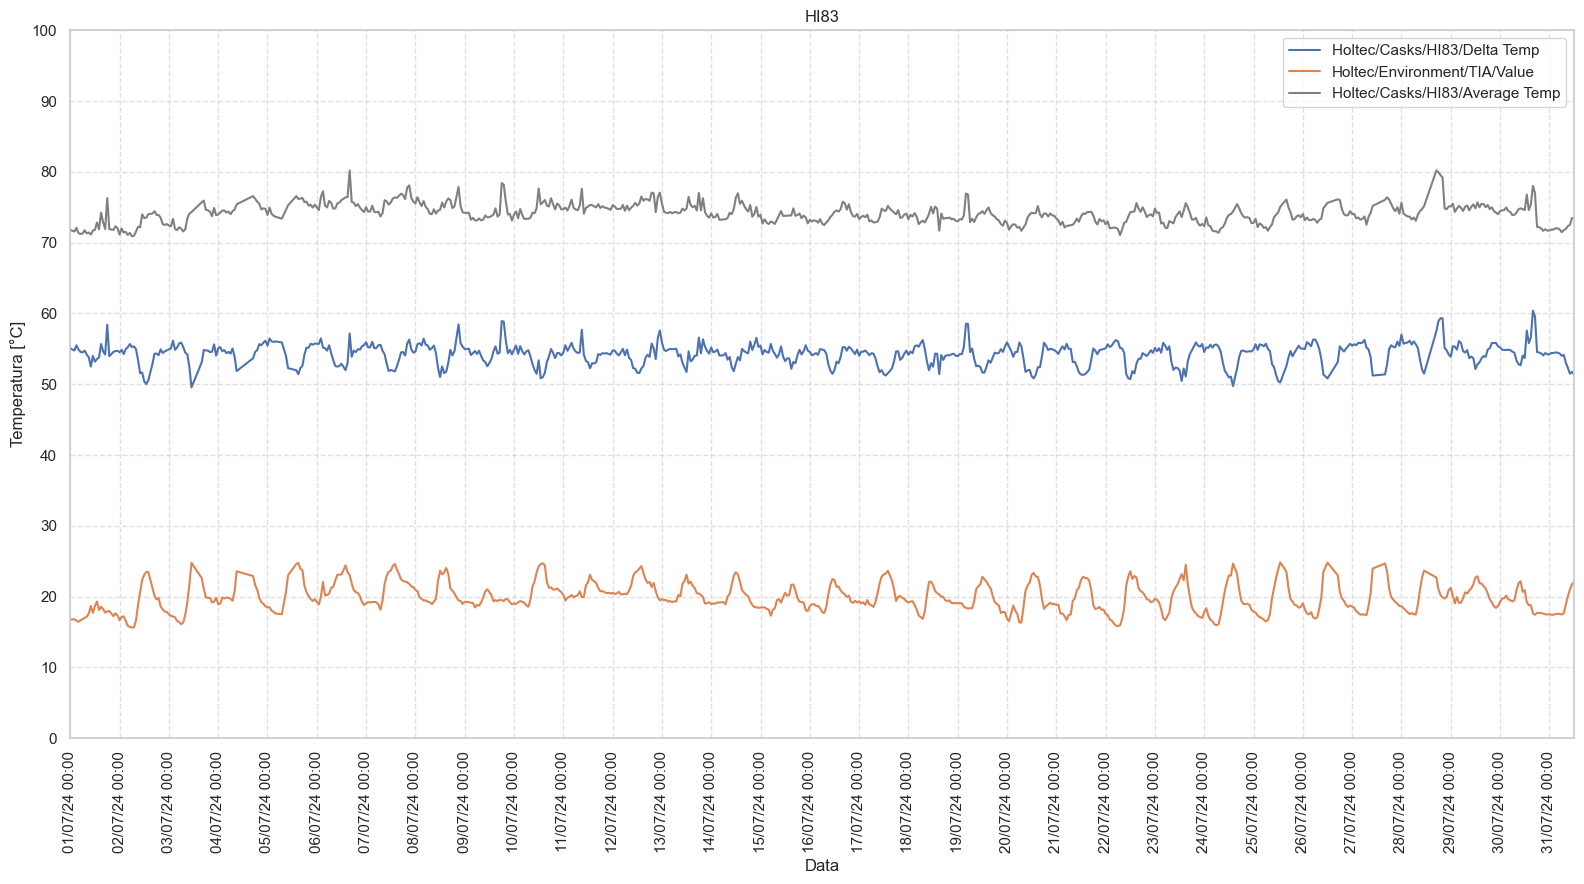

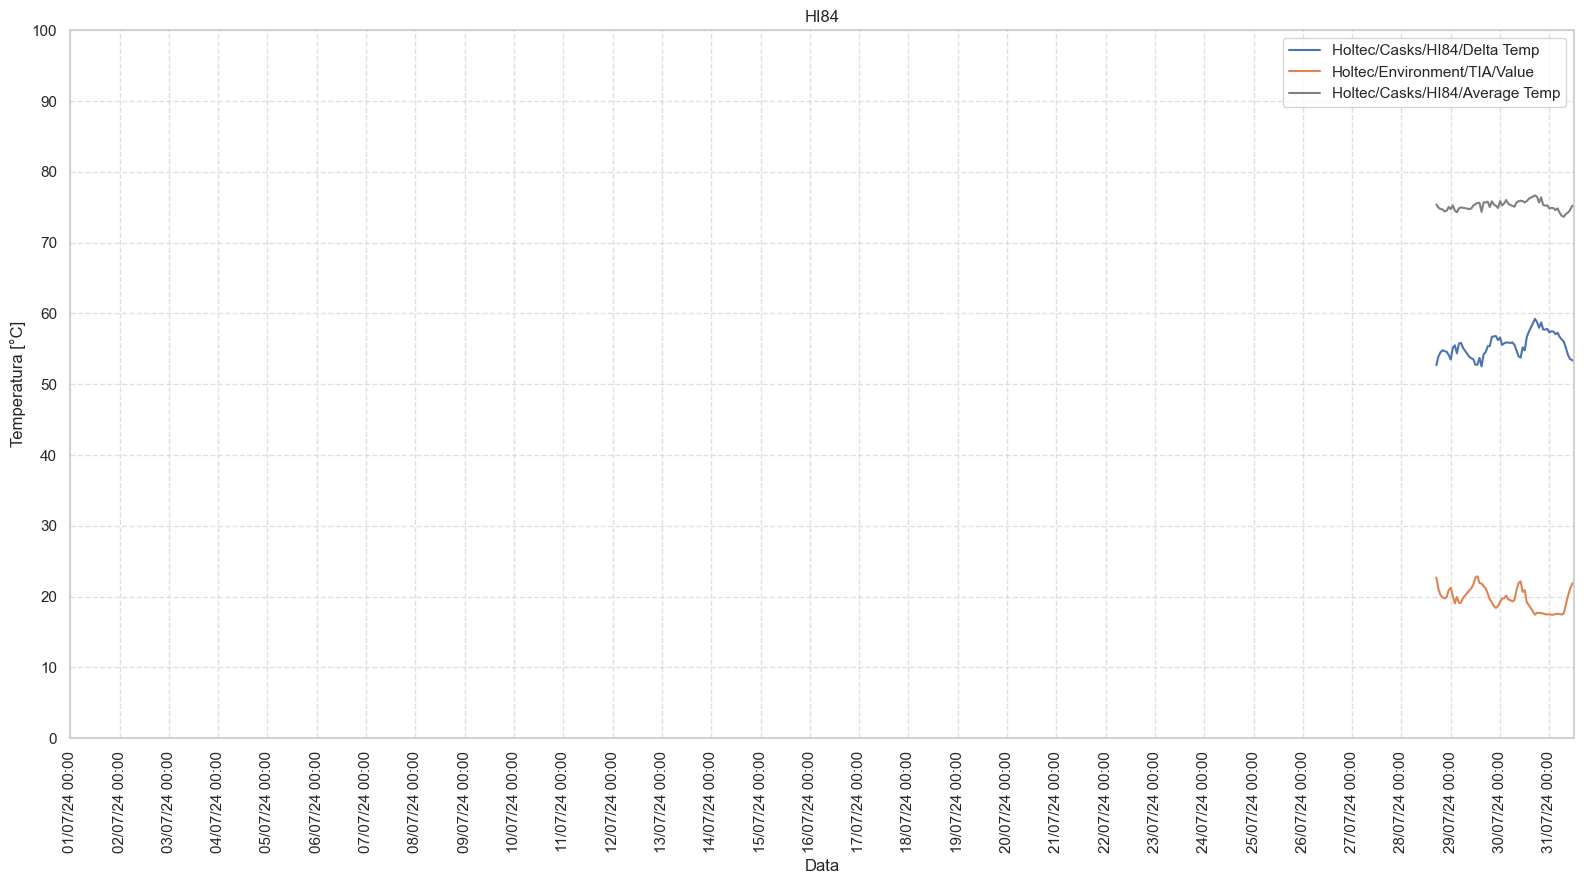

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns
import matplotlib.dates as mdates
import datetime
import os


def plot_all(file: str):
    # Read the data from the excel file
    df = pd.read_excel("cask data monthly july.xlsx")

    # Drop the columns that are not needed
    df = df[['Name', 't_stamp', 'EnvAvg', 'CaskAvg']]

    # Drop the rows that have missing values
    df = df[(df["CaskAvg"] > 0) & (df["EnvAvg"] > 0)]
    df = df.dropna()

    # Step 1: Apply zscore within each group
    df[['EnvAvg_z', 'CaskAvg_z']] = df.groupby('Name')[['EnvAvg', 'CaskAvg']].transform(zscore)

    # Step 2: Filter out the outliers (e.g., z-score greater than 2 or less than -2)
    z_score_threshold = 2
    df_filtered = df[(df['EnvAvg_z'].abs() <= z_score_threshold) & (df['CaskAvg_z'].abs() <= z_score_threshold)]

    # Drop the z-score columns if you don't need them anymore
    df_filtered = df_filtered.drop(columns=['EnvAvg_z', 'CaskAvg_z'])
    df = df_filtered

    # Set the style of the visualization
    sns.set_theme(style="whitegrid")

    # Group by 'Name'
    grouped = df_filtered.groupby('Name')
    
    # Get the maximum date from the 't_stamp' column and format it as 'MM.YYYY'
    month_year = df["t_stamp"].max().strftime("%m.%Y")

    # Create a plot for each group
    for name, group in grouped:
        plt.figure(figsize=(16, 9))
        plt.plot(group['t_stamp'], group['CaskAvg'] - group['EnvAvg'], label=f"Holtec/Casks/{name}/Delta Temp")
        plt.plot(group['t_stamp'], group['EnvAvg'], label=f"Holtec/Environment/TIA/Value")
        plt.plot(group['t_stamp'], group['CaskAvg'], label=f"Holtec/Casks/{name}/Average Temp", color='grey')
        
        # Add titles and labels
        plt.title(f'{name}')
        plt.xlabel('Data')
        plt.legend()
        plt.grid(alpha=0.6, linestyle="--")

        # Set xticks to every day at 00:00
        ax = plt.gca()
        # set xticks to every day
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        # format xticks as 'day/month/year'
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y %H:%M"))

        # set x-axis limits to first and last day
        start_date = datetime.datetime(
            df["t_stamp"].dt.year.max(),
            df["t_stamp"].dt.month.max(),
            df["t_stamp"].dt.day.min(),
        )
        end_date = datetime.datetime(
            df["t_stamp"].dt.year.max(),
            df["t_stamp"].dt.month.max(),
            df["t_stamp"].dt.day.max(),
            12,
            00,
            00,
        )
        ax.set_xlim([start_date, end_date])
        
        # Rotate x-axis labels for better readability
        plt.xticks(rotation=90)
        
        # Set y-axis labels and limits
        plt.ylabel("Temperatura [°C]")
        plt.ylim(0, 100)
        plt.yticks(range(0, 101, 10))
        
        # Show the plot
        plt.tight_layout()
        # Check if the directory exists and create it if it doesn't
        if not os.path.exists("plots"):
            os.makedirs("plots")

        # Save the plot
        plt.savefig(f"plots/{name}.png", dpi=300, format="png")

        # close the plot
        plt.close()

    # Return the maximum date in the 't_stamp' column, to be used in the report
    return month_year
        
plot_all("cask data monthly july.xlsx")